# VAYU - Predictive Modeling and Unsupervised Clustering of Ambient Air Quality Across Indian Urban Centres

**Dataset:** CPCB (Central Pollution Control Board) Sensor Data  
**Pipeline:** Data Cleaning → Regression → Classification → Clustering 

## Problem Statement

Air pollution is one of the most critical public health challenges in India. 
The Central Pollution Control Board (CPCB) operates a nationwide network of 
Continuous Ambient Air Quality Monitoring Stations (CAAQMS) that record 
concentrations of six key pollutants - PM2.5, PM10, NO2, SO2, CO, and O3 - 
on an hourly basis across Indian cities.

Despite the scale of this data collection effort, two fundamental challenges remain:

**1. Prediction (Supervised Learning)**  
Given the current pollutant concentrations and time context, can we accurately 
predict how bad the air quality is - either as a precise number (AQI) or as a 
human-interpretable category (Good / Moderate / Severe)?

**2. Pattern Discovery (Unsupervised Learning)**  
Without any labels, can we discover natural groupings among Indian cities based 
on their long-term pollution signatures - identifying which cities share similar 
chronic pollution patterns, seasonal behaviour, and dominant pollutants?

---

### Formal Problem Definitions

| Task | Type | Input | Output |
|---|---|---|---|
| **Task 1** | Regression | PM2.5, PM10, NO2, SO2, CO, O3 + time features | AQI as a continuous number (0–500) |
| **Task 2** | Classification | Same pollutant + time features + city | AQI category label: Good / Satisfactory / Moderate / Poor / Very Poor / Severe |
| **Task 3** | Clustering | City-level aggregated AQI profile (mean, std, seasonal means, pollutant dominance) | Cluster assignment - which cities are pollution-similar? |

---

### Why This Problem Matters

- India has **14 of the world's 20 most polluted cities** (IQAir 2023)
- CPCB's AQI threshold of 200 (Moderate) triggers public health advisories
- Predicting AQI from raw sensor readings enables **early warning systems**
- Clustering cities by pollution signature enables **targeted policy interventions** - 
  PM2.5-heavy northern cities need different solutions than ozone-heavy southern cities

---

The output of this notebook is `master_cleaned.csv` - the single source of truth 
that feeds all four ML tasks above.

## Dataset

### Primary Source - `aqi_india_38cols_knn_final.csv`

| Property | Value |
|---|---|
| Rows | 846,372 |
| Cities | 29 Indian cities |
| Time range | 2015 – 2024 (hourly) |
| Pollutants | PM2.5, PM10, NO2, SO2, CO, O3 |
| Pre-processing | None |
| Known issue | Sentinel value **999** used by CPCB to flag sensor errors |

### Secondary Source - 277 `*_AQIBulletins.csv` files

| Property | Value |
|---|---|
| Files | 277 (one per city) |
| Cities covered | 277 Indian cities |
| Data type | Daily aggregated AQI only (no raw pollutant readings) |
| Used for | K-Means clustering task only |

### Why These Sources Were Chosen

The primary file was selected from a scan of **299 raw files** because it is the only 
file that combines all of: 842k rows of depth, all 6 CPCB pollutants, 9 years of 
temporal coverage, and 29 cities in a single consistent schema.

The bulletin files were chosen for clustering because they cover **277 cities** - 
giving far richer geographic spread than the 29-city primary file.

## Data Access

This notebook downloads the raw CPCB dataset directly from HuggingFace and runs the full pipeline — cleaning, encoding, feature selection, and model training — from scratch.

| Repository | Contents | Path after download |
|---|---|---|
| `rachitgoyell/vayu-raw` | 299 raw CPCB CSV files | `./data/raw/` |

No manual downloading or path changes needed — just run the cell below and everything sets up automatically.

> **Note:** The repository is public. No HuggingFace token is required.

In [4]:
# ── HuggingFace Dataset Setup ─────────────────────────────────────────────────
import os
from huggingface_hub import snapshot_download

HF_USERNAME = "rachitgoyell"

# download raw data → ./data/raw/
# the cleaning pipeline in this notebook produces all cleaned outputs itself
# so we only need the raw files here
snapshot_download(
    repo_id   = f"{HF_USERNAME}/vayu-raw",
    repo_type = "dataset",
    local_dir = "./data/raw"
)

# create the output folder structure the pipeline will write to
for folder in ['01_regression', '02_classification', '03_clustering', '05_shared']:
    os.makedirs(f'./data/cleaned/{folder}', exist_ok=True)

DATA_ROOT   = './data/raw'
OUTPUT_ROOT = './data/cleaned'

print("data/raw/     - raw files ready")
print("data/cleaned/ - output folders created")
print(f"\nRaw files available: {len(os.listdir(DATA_ROOT))}")

Fetching 301 files: 100%|██████████| 301/301 [00:00<00:00, 421.81it/s]

data/raw/     - raw files ready
data/cleaned/ - output folders created

Raw files available: 302


<!-- dataset_audit.md -->

## Dataset Audit — What We Have and What We're Actually Using

Before loading anything, we did a full scan of all the raw files in our data folder. There were about 299 files in total — CSVs and a few Excel files. Most of them turned out to be useless for what we're trying to do. Here's what we found and why we made the choices we did.

### The Two Sources We're Actually Using

**Primary file — `aqi_india_38cols_knn_final.csv`**
This is the main dataset. 842,160 rows of hourly sensor readings from 29 Indian cities, with all six pollutants (PM2.5, PM10, NO2, SO2, CO, O3) and an AQI category label. This feeds our regression and classification tasks. It's the only file in the whole dump that has raw pollutant readings at scale — everything else either has too few rows or is missing key columns.

**277 AQI Bulletin files — `*_AQIBulletins.csv`**
One file per Indian city, each containing daily AQI summaries. These don't have individual pollutant readings — just the final AQI number and which pollutant was dominant that day. Useless for regression (no features to train on), but perfect for clustering since they cover 277 cities. More geographic spread means better clusters.

### What We Rejected and Why

| Category | Example Files | Rejection Reason |
|---|---|---|
| API snapshots | `AQI.csv`, `Data Export.csv`, `3b01bcb8...csv` | Only 200 rows each — point-in-time API exports, not time series |
| Single station hourly | `AshokVihar_Hourly.csv`, `Okhla_Hourly.csv` | No city column, single Delhi station only, can't be joined |
| Small academic datasets | `Dataset_AQI21-4.xlsx`, `Cleaned_NSUT.xlsx` | 153–200 rows, manually compiled research files |
| Malformed files | `data_aqi_cpcb.csv` | 6,011 columns, 92% empty — JSON that got flattened incorrectly |
| Wrong schema | `AQI Data.csv` | Contains weather columns (temperature, pressure) but no AQI or pollutant data |

The code below scans the data folder, classifies each file, and produces a summary so this decision is reproducible — not just something we eyeballed once.

Total files found: 300

  FILE AUDIT RESULTS
  Total scanned : 300
  Accepted      : 278
    Primary file         : 1
    AQI Bulletin files   : 277
  Rejected      : 22

  Rejected files:
    3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv      -> only 200 rows - snapshot or sample, not a time series
    AP001.csv                                     -> only 200 rows - snapshot or sample, not a time series
    AQI Data.csv                                  -> no date or city column - cannot use
    AQI.csv                                       -> only 200 rows - snapshot or sample, not a time series
    AshokVihar_Hourly.csv                         -> no date or city column - cannot use
    Cleaned_NSUT.xlsx                             -> could not be read: Missing optional dependency 'openpyxl'.  Use pip or conda to
    DCStadium_Hourly.csv                          -> no date or city column - cannot use
    Data Export.csv                               -> only 200 rows - snapshot or sample, n

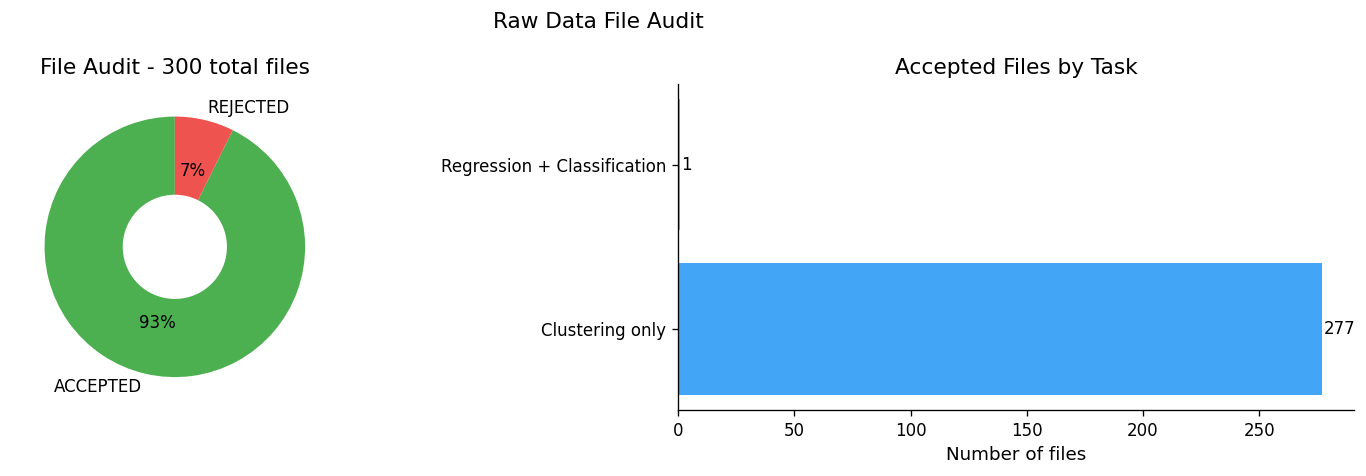

In [5]:
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_ROOT        = './data/raw'
PRIMARY_FILE     = 'aqi_india_38cols_knn_final.csv'
BULLETIN_PATTERN = 'AQIBulletins'

# keywords that tell us a file has actual pollutant readings
POLLUTANT_KW = ['pm2', 'pm10', 'no2', 'so2', 'co', 'o3']
BULLETIN_KW  = ['index', 'air', 'quality', 'pollutant']

all_files = (
    glob.glob(os.path.join(DATA_ROOT, '**/*.csv'),  recursive=True) +
    glob.glob(os.path.join(DATA_ROOT, '**/*.xlsx'), recursive=True)
)

print(f'Total files found: {len(all_files)}\n')

results = []

for fp in sorted(all_files):
    fname = os.path.basename(fp)
    rel   = os.path.relpath(fp, DATA_ROOT)

    # the two files we actually want - mark them accepted immediately
    if PRIMARY_FILE in fname:
        results.append({
            'file'    : rel,
            'status'  : 'ACCEPTED',
            'used_for': 'Regression + Classification',
            'reason'  : '842k rows, all 6 pollutants, 29 cities'
        })
        continue

    if BULLETIN_PATTERN in fname:
        results.append({
            'file'    : rel,
            'status'  : 'ACCEPTED',
            'used_for': 'Clustering only',
            'reason'  : 'Daily AQI history across 277 cities'
        })
        continue

    # for everything else, read the first 200 rows and diagnose
    try:
        df_s = (
            pd.read_excel(fp, nrows=200)
            if fname.endswith('.xlsx')
            else pd.read_csv(fp, nrows=200, low_memory=False, encoding_errors='replace')
        )

        col_str  = ' '.join(c.lower() for c in df_s.columns)
        null_pct = df_s.isnull().mean().mean() * 100
        n_rows   = len(df_s)

        has_pollutants = any(k in col_str for k in POLLUTANT_KW)
        has_bulletin   = any(k in col_str for k in BULLETIN_KW)
        has_city       = any(k in col_str for k in ['city', 'station'])
        has_date       = any(k in col_str for k in ['date', 'time', 'datetime'])

        if null_pct > 80:
            reason = f'{null_pct:.0f}% cells empty - malformed file'
        elif not has_date and not has_city:
            reason = 'no date or city column - cannot use'
        elif not has_pollutants and not has_bulletin:
            reason = 'no pollutant or AQI columns found'
        elif has_pollutants and n_rows < 10000:
            reason = f'only {n_rows} rows - snapshot or sample, not a time series'
        else:
            reason = 'schema does not match any expected format'

        results.append({
            'file'    : rel,
            'status'  : 'REJECTED',
            'used_for': '-',
            'reason'  : reason
        })

    except Exception as e:
        results.append({
            'file'    : rel,
            'status'  : 'REJECTED',
            'used_for': '-',
            'reason'  : f'could not be read: {str(e)[:60]}'
        })

# summary
audit_df  = pd.DataFrame(results)
accepted  = audit_df[audit_df['status'] == 'ACCEPTED']
rejected  = audit_df[audit_df['status'] == 'REJECTED']

print(f'{"="*55}')
print(f'  FILE AUDIT RESULTS')
print(f'{"="*55}')
print(f'  Total scanned : {len(audit_df)}')
print(f'  Accepted      : {len(accepted)}')
print(f'    Primary file         : 1')
print(f'    AQI Bulletin files   : {len(accepted) - 1}')
print(f'  Rejected      : {len(rejected)}')
print()

# rejection breakdown
print('  Rejected files:')
for _, row in rejected.iterrows():
    print(f'    {row["file"]:<45} -> {row["reason"]}')

# bar chart - accepted vs rejected
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

status_counts = audit_df['status'].value_counts()
axes[0].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=['#4CAF50', '#EF5350'],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)
axes[0].set_title(f'File Audit - {len(audit_df)} total files')

# accepted breakdown by use
accepted_uses = accepted['used_for'].value_counts()
colors_use    = ['#42A5F5', '#FF9800']
bars          = axes[1].barh(accepted_uses.index, accepted_uses.values,
                              color=colors_use[:len(accepted_uses)])
for bar, val in zip(bars, accepted_uses.values):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontsize=10)
axes[1].set_xlabel('Number of files')
axes[1].set_title('Accepted Files by Task')

plt.suptitle('Raw Data File Audit', fontsize=13)
plt.tight_layout()
plt.show()

<!-- section_1.md -->

## Section 1 - Loading the Primary Dataset

Alright, let's actually load the file we're going to spend most of this notebook on. This is `aqi_india_38cols_knn_final.csv` — the 842k row hourly sensor dataset covering 29 Indian cities from 2022 to 2025.

The first thing we do after loading is just look at the structure. How many rows and columns? What are the data types? Are there any columns that should be numeric but got read in as strings? That last one is a sneaky problem — if a column has even one bad value in it, pandas sometimes reads the whole column as `object` instead of `float64`, and then your `.describe()` gives you nothing useful.

We also want to get a feel for which columns are actually relevant to our models. Not all 31 columns are going into every model — some are identity columns (city, state, coordinates), some are datetime-derived features (month, hour, season), some are the actual pollutant readings we care about, and one is our target variable (`aqi_category`).

One thing worth noting upfront — this file was KNN-imputed before we got it. That means whoever put it on Kaggle already went through and filled in the obvious NaN gaps using a nearest-neighbour approach. So `df.isnull().sum()` will return near-zero counts, and that's expected. The real issue we found — the CPCB sentinel value 999 — is completely invisible to `isnull()`. We'll get to that in the cleaning section.

Shape   : 846,371 rows  x  31 columns
Memory  : 677.3 MB

Column dtypes:
float64    18
object     13

  Column                    dtype           Nulls   Sample value
  city                      object           4236   agartala
  state                     object           4229   tripura
  latitude                  float64          4235   23.8315
  longitude                 float64          4232   91.2868
  datetime                  object           4236   2022-08-05 00:00:00
  month                     float64          4222   8.0
  day_name                  object           4232   friday
  is_weekend                object           4233   False
  season                    object           4232   monsoon
  time_of_day               object           4228   night
  humidity_percent          float64          4231   91.0
  dew_point_c               float64          4229   25.1
  wind_gusts_kmh            float64          4231   11.2
  precipitation_mm          float64          4242   0.0
  

,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3
count,842144.00,842141.00,842141.00,842138.00,842136.00,842139.00
mean,34.55,54.01,444.97,15.99,13.39,80.19
std,29.66,54.23,377.02,19.90,18.92,44.77
min,1.90,2.30,96.00,0.00,0.20,0.00
25%,14.70,21.50,235.00,3.70,2.80,47.00
50%,25.90,39.00,333.00,9.00,6.90,73.00
75%,44.20,66.40,508.00,19.90,15.80,108.00
max,183.50,420.00,2903.00,122.10,134.20,228.00


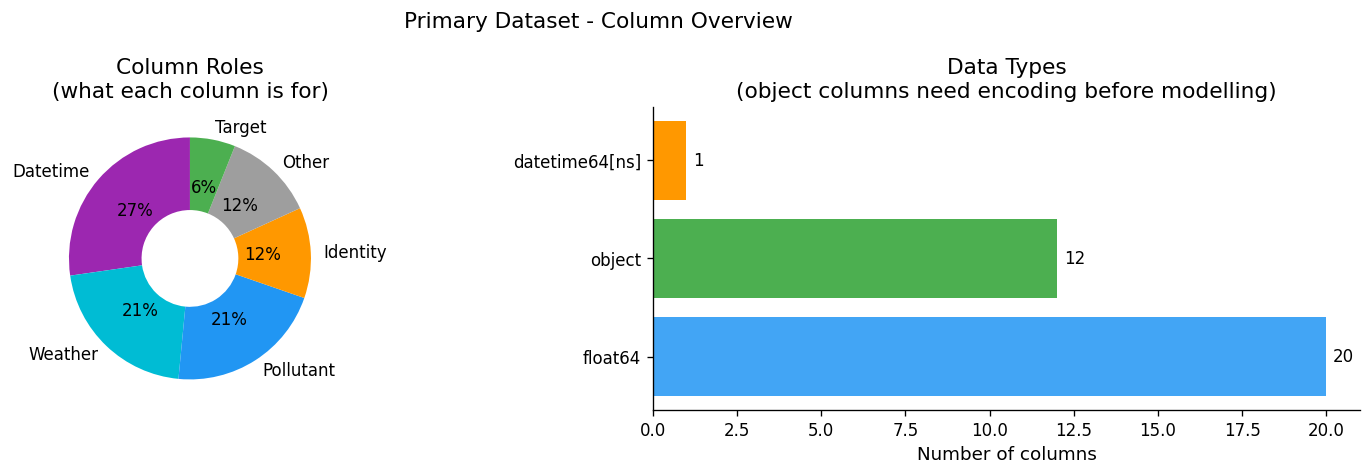

In [27]:
# ── load the primary dataset ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
sns.set_palette('muted')

pd.set_option('display.max_columns', 60)

DATA_PATH = './data/raw/aqi_india_38cols_knn_final.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Shape   : {df.shape[0]:,} rows  x  {df.shape[1]} columns')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

# ── column type overview ──────────────────────────────────────────────────────
print(f'\nColumn dtypes:')
print(df.dtypes.value_counts().to_string())

# ── quick look at every column ────────────────────────────────────────────────
print(f'\n{"="*65}')
print(f'  {"Column":<25} {"dtype":<12} {"Nulls":>8}   Sample value')
print(f'{"="*65}')
for col in df.columns:
    dtype  = str(df[col].dtype)
    nulls  = df[col].isnull().sum()
    sample = str(df[col].dropna().iloc[0])[:25] if df[col].notna().any() else 'N/A'
    print(f'  {col:<25} {dtype:<12} {nulls:>8}   {sample}')

# ── identify columns we care about ───────────────────────────────────────────
# co_ with underscore avoids matching cloud_cover_percent
POLLUTANT_KW = ['pm2', 'pm10', 'no2', 'so2', 'co_', 'o3']
EXCLUDE_KW   = ['cloud', 'cover', 'humidity', 'temp', 'pressure',
                'wind', 'rain', 'solar', 'dew', 'uv']

pollutant_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if any(k in c.lower() for k in POLLUTANT_KW)
    and not any(e in c.lower() for e in EXCLUDE_KW)
]

city_col = next((c for c in df.columns if c.lower() in ['city', 'city_name']), None)
date_col = next((c for c in df.columns if 'datetime' in c.lower()
                 or c.lower() == 'date'), None)
cat_col  = next((c for c in df.columns if 'category' in c.lower()
                 or 'bucket' in c.lower()), None)

print(f'\nPollutant columns detected : {pollutant_cols}')
print(f'City column                : {city_col}')
print(f'Datetime column            : {date_col}')
print(f'Target column              : {cat_col}')

# ── derive hour and day_of_week if not already present ───────────────────────
# these are useful temporal features for both regression and classification
# the dataset may already have them - we only create them if missing
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

if 'hour' not in df.columns:
    df['hour'] = df[date_col].dt.hour
    print('hour column derived from datetime')
else:
    print('hour column already present')

if 'day_of_week' not in df.columns:
    df['day_of_week'] = df[date_col].dt.dayofweek
    print('day_of_week column derived from datetime')
else:
    print('day_of_week column already present')

# ── basic statistics on pollutant columns ────────────────────────────────────
print(f'\nDescriptive stats - pollutant columns:')
display(df[pollutant_cols].describe().round(2))

# ── column role classification ────────────────────────────────────────────────
def classify_col(col):
    cl = col.lower()
    if any(k in cl for k in POLLUTANT_KW) and not any(e in cl for e in EXCLUDE_KW):
        return 'Pollutant'
    elif any(k in cl for k in ['aqi', 'category', 'bucket']):
        return 'Target'
    elif any(k in cl for k in ['city', 'state', 'lat', 'lon']):
        return 'Identity'
    elif any(k in cl for k in ['date', 'time', 'year', 'month',
                                'day', 'hour', 'week', 'season']):
        return 'Datetime'
    elif any(k in cl for k in ['humidity', 'temp', 'pressure', 'wind',
                                'rain', 'cloud', 'dew']):
        return 'Weather'
    else:
        return 'Other'

role_series = pd.Series({c: classify_col(c) for c in df.columns})
role_counts = role_series.value_counts()

role_colors = {
    'Pollutant': '#2196F3',
    'Target'   : '#4CAF50',
    'Identity' : '#FF9800',
    'Datetime' : '#9C27B0',
    'Weather'  : '#00BCD4',
    'Other'    : '#9E9E9E',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].pie(
    role_counts.values,
    labels=role_counts.index,
    colors=[role_colors[r] for r in role_counts.index],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(width=0.6)
)
axes[0].set_title('Column Roles\n(what each column is for)')

dtype_counts = df.dtypes.astype(str).value_counts()
bars = axes[1].barh(
    dtype_counts.index,
    dtype_counts.values,
    color=['#42A5F5', '#4CAF50', '#FF9800', '#9E9E9E'][:len(dtype_counts)]
)
for bar, val in zip(bars, dtype_counts.values):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                 str(val), va='center', fontsize=10)
axes[1].set_xlabel('Number of columns')
axes[1].set_title('Data Types\n(object columns need encoding before modelling)')

plt.suptitle('Primary Dataset - Column Overview', fontsize=13)
plt.tight_layout()
plt.show()

<!-- section_2_eda.md -->

## Section 2 - Exploratory Data Analysis

Before we fix anything we need to understand what's actually wrong. This section is purely observation — not changing a single value. Three things we're looking for:

1. Are there missing values and where?
2. Are there garbage values hiding in the data that pandas can't see?
3. How are the pollutant readings distributed — do they look physically real?

One thing worth knowing upfront — this file was KNN-imputed before we got it, meaning the obvious NaN gaps were already filled. So `isnull()` will return near-zero counts and that's expected. The real problem is the CPCB sentinel value **999**, which the sensor logs whenever a station goes offline. Pandas treats 999 as a perfectly valid number, so we have to hunt for it manually.

Standard NaN per pollutant column:
  pm2_5_ugm3                4,227
  pm10_ugm3                 4,230
  co_ugm3                   4,230
  no2_ugm3                  4,233
  so2_ugm3                  4,235
  o3_ugm3                   4,232

Sentinel 999 per pollutant column:
  pm2_5_ugm3                0
  pm10_ugm3                 0
  co_ugm3                   124  <- needs fixing
  no2_ugm3                  0
  so2_ugm3                  0
  o3_ugm3                   0

Physical range check per pollutant:
  pm2_5_ugm3                range [0 – 1,000]   flagged: 0  OK
  pm10_ugm3                 range [0 – 1,500]   flagged: 0  OK
  co_ugm3                   range [0 – 50,000]   flagged: 0  OK
  no2_ugm3                  range [0 – 500]   flagged: 0  OK
  so2_ugm3                  range [0 – 500]   flagged: 0  OK
  o3_ugm3                   range [0 – 300]   flagged: 0  OK


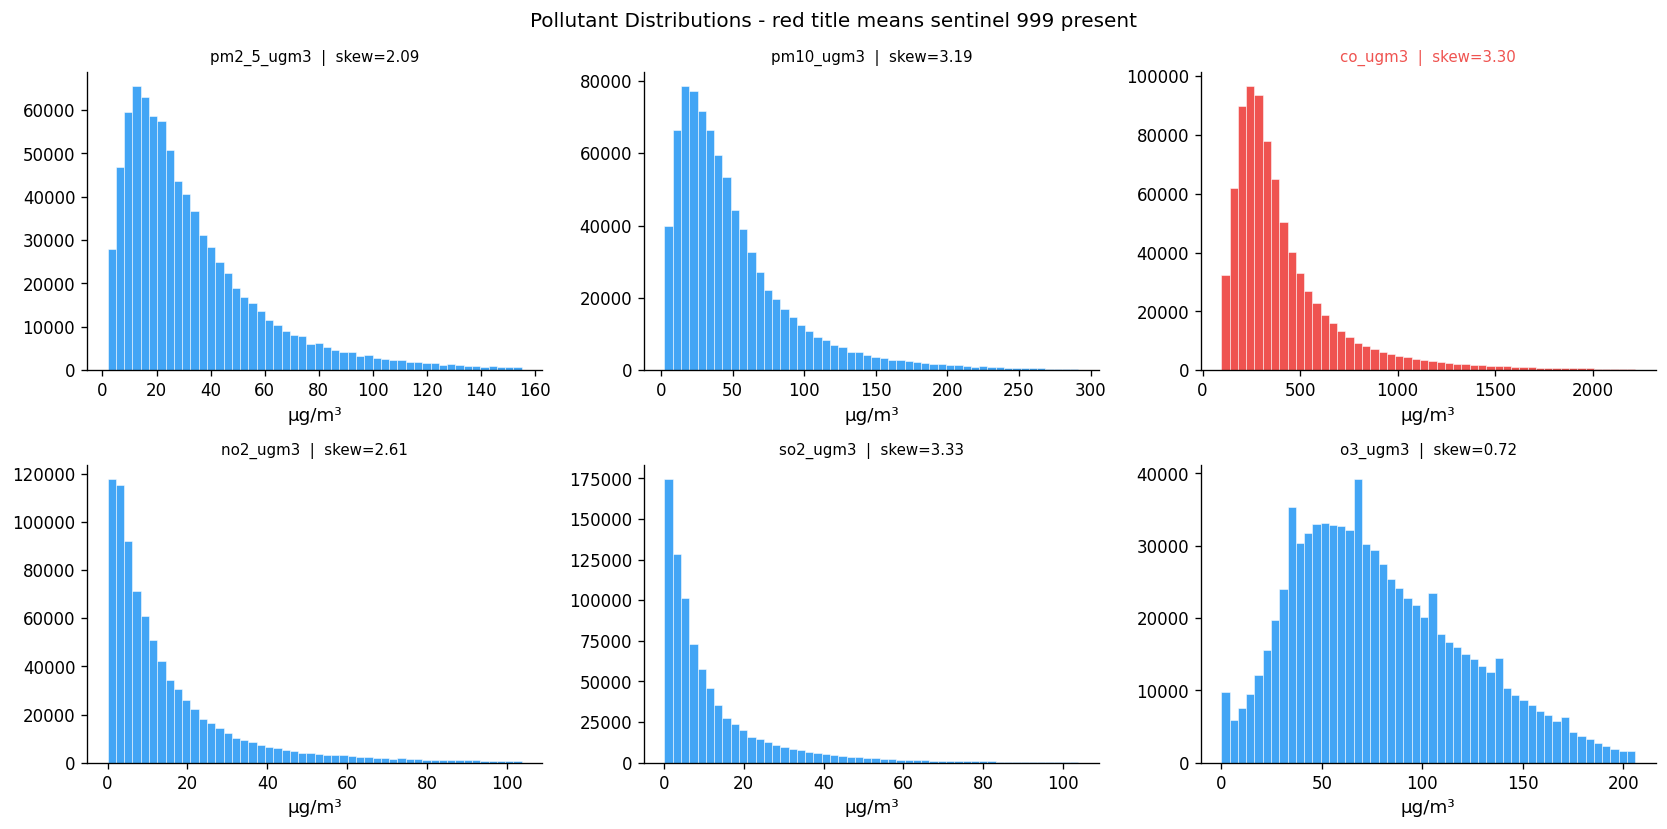

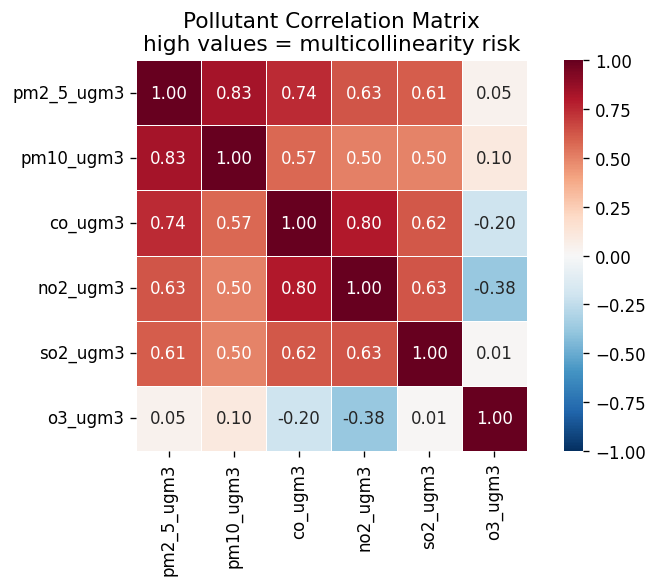


AQI category distribution:
  Moderate                   385,833  (45.6%)
  Unhealthy for Sensitive Groups  175,148  (20.7%)
  Good                       136,452  (16.1%)
  Unhealthy                  130,340  (15.4%)
  Very Unhealthy              14,370  (1.7%)

Class imbalance ratio : 26.8x


In [28]:
# section_2_eda.py

# ── missing values + sentinel 999 ────────────────────────────────────────────
print('Standard NaN per pollutant column:')
for col in pollutant_cols:
    n = df[col].isnull().sum()
    print(f'  {col:<25} {n:,}')

print('\nSentinel 999 per pollutant column:')
for col in pollutant_cols:
    count = (pd.to_numeric(df[col], errors='coerce') == 999).sum()
    flag  = '  <- needs fixing' if count > 0 else ''
    print(f'  {col:<25} {count:,}{flag}')

# ── physical range validation ─────────────────────────────────────────────────
# just because a value isn't 999 doesn't mean it's real
# a broken sensor can output 47000 for PM2.5 which is physically impossible
# we check each pollutant against CPCB's known instrument limits

VALID_RANGES = {
    'pm2'  : (0, 1000),
    'pm10' : (0, 1500),
    'no2'  : (0, 500),
    'so2'  : (0, 500),
    'co'   : (0, 50000),  # stored as µg/m³ so 50 mg/m³ × 1000 = 50,000
    'o3'   : (0, 300),
    'nh3'  : (0, 400),
}

print('\nPhysical range check per pollutant:')
for col in pollutant_cols:
    vals          = pd.to_numeric(df[col], errors='coerce').dropna()
    matched_range = next(
        ((lo, hi) for kw, (lo, hi) in VALID_RANGES.items() if kw in col.lower()),
        None
    )
    if matched_range:
        lo, hi        = matched_range
        out_of_range  = ((vals < lo) | (vals > hi)).sum()
        flag          = '  <- out of range values found' if out_of_range > 0 else '  OK'
        print(f'  {col:<25} range [{lo:,} – {hi:,}]   flagged: {out_of_range:,}{flag}')
    else:
        print(f'  {col:<25} no range rule - skipped')

# ── pollutant distributions ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    vals         = pd.to_numeric(df[col], errors='coerce').dropna()
    sentinel_pct = (vals == 999).mean() * 100
    color        = '#EF5350' if sentinel_pct > 0 else '#42A5F5'
    axes[i].hist(vals[vals <= vals.quantile(0.99)], bins=50,
                 color=color, edgecolor='white', linewidth=0.3)
    axes[i].set_title(f'{col}  |  skew={vals.skew():.2f}', fontsize=9,
                      color='#EF5350' if sentinel_pct > 0 else 'black')
    axes[i].set_xlabel('µg/m³')

plt.suptitle('Pollutant Distributions - red title means sentinel 999 present', fontsize=12)
plt.tight_layout()
plt.show()

# ── correlation heatmap ───────────────────────────────────────────────────────
corr_mat = df[pollutant_cols].apply(pd.to_numeric, errors='coerce').corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Pollutant Correlation Matrix\nhigh values = multicollinearity risk')
plt.tight_layout()
plt.show()

# ── aqi category balance ──────────────────────────────────────────────────────
cat_counts = df[cat_col].value_counts()
print(f'\nAQI category distribution:')
for cat, cnt in cat_counts.items():
    print(f'  {cat:<25} {cnt:>8,}  ({cnt/len(df)*100:.1f}%)')

print(f'\nClass imbalance ratio : {cat_counts.max()/cat_counts.min():.1f}x')

<!-- section_3_cleaning.md -->

## Section 3 — Data Cleaning

Now that we know what's wrong, we fix it. In order. The order matters — if we forward fill before removing the 999 sentinel values, we'd propagate fake readings into neighbouring rows.

Here's what we're doing and why:

1. **Replace sentinel 999 with NaN** — 999 is not a real reading, it's a sensor error code. If we leave it in, the model learns that PM2.5 = 999 predicts some AQI value, which is completely wrong.

2. **Physical range validation** — after removing sentinels, any remaining value outside the physically possible range is a sensor malfunction. We null those too.

3. **Forward fill short gaps** — after nulling bad values, some rows have NaN. If the gap is 3 hours or less, we carry the last known reading forward. Pollutant concentrations don't change that fast, so this is a reasonable estimate. Gaps longer than 3 hours stay NaN — too stale to guess.

4. **Drop rows where all pollutants are NaN** — if every single pollutant column is NaN for a row, there's nothing to work with. Drop it.

5. **Drop duplicates** — CPCB exports sometimes produce duplicate rows when date ranges overlap. We deduplicate on city + datetime.

6. **Fix dtypes** — make sure datetime is parsed properly and category labels are standardised.

We log the row count before and after each step so we can see exactly what each operation cost us.

  [sentinel 999 -> NaN]  846,371 -> 846,371  (0 removed)  1,476 values replaced
  [range validation]  846,371 -> 846,371  (0 removed)  0 out-of-range values nulled
  [forward fill (limit=3)]  846,371 -> 846,371  (0 removed)  94 gaps filled, 25,417 remain
  [drop all-null rows]  846,371 -> 842,135  (4,236 removed)  rows with no usable pollutant readings  <- rows dropped
  [deduplication]  842,135 -> 833,786  (8,349 removed)  deduplicated on (city, datetime)  <- rows dropped
  [dtype fix + label standardise]  833,786 -> 833,786  (0 removed)  datetime parsed, 4,169 unmapped category rows

  CLEANING SUMMARY
                         step  before  after  removed                                          note
          sentinel 999 -> NaN  846371 846371        0                         1,476 values replaced
             range validation  846371 846371        0                  0 out-of-range values nulled
       forward fill (limit=3)  846371 846371        0                 94 gaps filled, 25

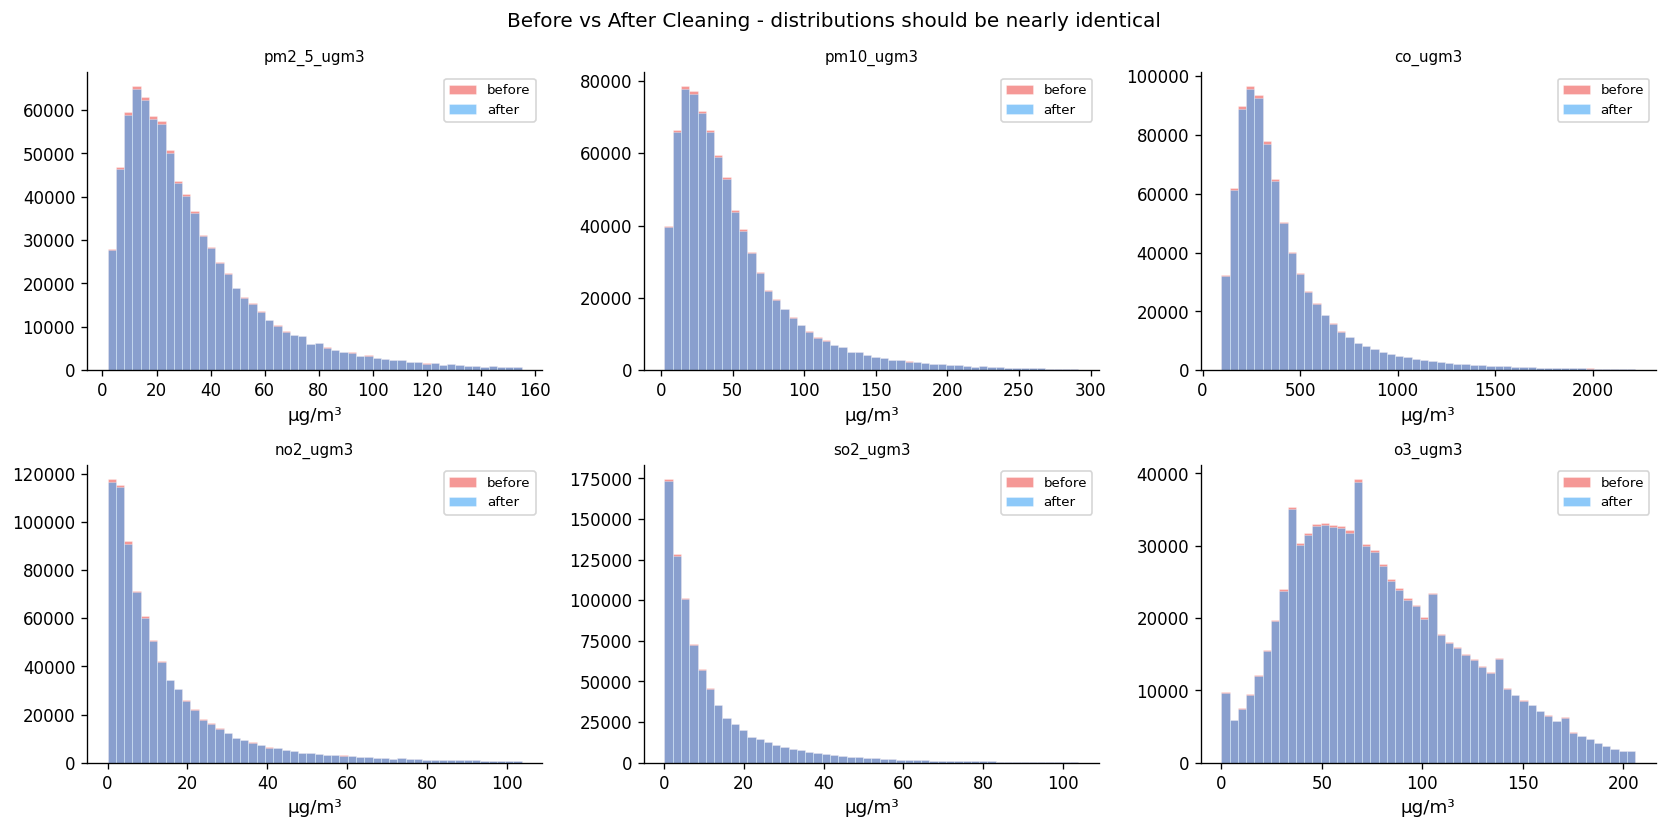


Saved master cleaned file to ./data/cleaned/04_shared/master_cleaned.csv


In [29]:
cleaning_log = []

def log_step(name, before, after, note=''):
    removed = before - after
    cleaning_log.append({
        'step': name, 'before': before,
        'after': after, 'removed': removed, 'note': note
    })
    flag = '  <- rows dropped' if removed > 0 else ''
    print(f'  [{name}]  {before:,} -> {after:,}  '
          f'({removed:,} removed)  {note}{flag}')

# take a snapshot before touching anything - used for before/after plots
df_raw_snapshot = df[pollutant_cols].copy()

# ── step 1 - replace sentinel 999 with NaN ───────────────────────────────────
before       = len(df)
replacements = 0
for col in df.select_dtypes(include=[np.number]).columns:
    mask          = df[col] == 999
    replacements += mask.sum()
    df.loc[mask, col] = np.nan

log_step('sentinel 999 -> NaN', before, len(df),
         f'{replacements:,} values replaced')

# ── step 2 - physical range validation ───────────────────────────────────────
before       = len(df)
total_nulled = 0

for col in pollutant_cols:
    matched = next(
        ((lo, hi) for kw, (lo, hi) in VALID_RANGES.items() if kw in col.lower()),
        None
    )
    if matched:
        lo, hi = matched
        vals   = pd.to_numeric(df[col], errors='coerce')
        mask   = (vals < lo) | (vals > hi)
        df.loc[mask, col] = np.nan
        total_nulled += mask.sum()

log_step('range validation', before, len(df),
         f'{total_nulled:,} out-of-range values nulled')

# ── step 3 - forward fill short sensor gaps (max 3 hours, per city) ──────────
before           = len(df)
null_before_fill = df[pollutant_cols].isnull().sum().sum()

df = df.sort_values([city_col, date_col]).reset_index(drop=True)
df[pollutant_cols] = (
    df.groupby(city_col)[pollutant_cols]
    .transform(lambda x: x.ffill(limit=3))
)

filled = null_before_fill - df[pollutant_cols].isnull().sum().sum()
log_step('forward fill (limit=3)', before, len(df),
         f'{filled:,} gaps filled, '
         f'{df[pollutant_cols].isnull().sum().sum():,} remain')

# ── step 4 - drop rows where every pollutant is still NaN ────────────────────
before = len(df)
df     = df[~df[pollutant_cols].isnull().all(axis=1)].reset_index(drop=True)
log_step('drop all-null rows', before, len(df),
         'rows with no usable pollutant readings')

# ── step 5 - deduplication ────────────────────────────────────────────────────
before = len(df)
df     = df.drop_duplicates(subset=[city_col, date_col],
                             keep='first').reset_index(drop=True)
log_step('deduplication', before, len(df),
         f'deduplicated on ({city_col}, {date_col})')

# ── step 6 - fix dtypes ───────────────────────────────────────────────────────
before           = len(df)
df[date_col]     = pd.to_datetime(df[date_col], errors='coerce')

# standardise aqi category labels to CPCB naming convention
CAT_MAP = {
    'good'                   : 'Good',
    'satisfactory'           : 'Satisfactory',
    'moderate'               : 'Moderate',
    'poor'                   : 'Poor',
    'very poor'              : 'Very Poor',
    'severe'                 : 'Severe',
    'unhealthy for sensitive': 'Poor',
    'unhealthy'              : 'Very Poor',
    'very unhealthy'         : 'Severe',
    'hazardous'              : 'Severe',
}

df[cat_col] = (
    df[cat_col].astype(str).str.strip().str.lower()
    .map(lambda x: next((v for k, v in CAT_MAP.items() if k in x), None))
)

unmapped = df[cat_col].isnull().sum()
log_step('dtype fix + label standardise', before, len(df),
         f'datetime parsed, {unmapped:,} unmapped category rows')

# ── cleaning summary ──────────────────────────────────────────────────────────
print(f'\n{"="*55}')
print('  CLEANING SUMMARY')
print(f'{"="*55}')
print(pd.DataFrame(cleaning_log)[['step','before','after','removed','note']]
      .to_string(index=False))
print(f'\n  Final row count : {len(df):,}')

# ── before vs after distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    raw     = pd.to_numeric(df_raw_snapshot[col], errors='coerce').dropna()
    cleaned = pd.to_numeric(df[col], errors='coerce').dropna()
    cap     = raw.quantile(0.99)

    axes[i].hist(raw[raw <= cap],         bins=50, color='#EF5350',
                 alpha=0.6, label='before', edgecolor='white', linewidth=0.3)
    axes[i].hist(cleaned[cleaned <= cap], bins=50, color='#42A5F5',
                 alpha=0.6, label='after',  edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('µg/m³')
    axes[i].legend(fontsize=8)

plt.suptitle('Before vs After Cleaning - distributions should be nearly identical',
             fontsize=12)
plt.tight_layout()
plt.show()

# ── save master cleaned file ──────────────────────────────────────────────────
import os
SHARED_DIR = './data/cleaned/04_shared'
os.makedirs(SHARED_DIR, exist_ok=True)

df.to_csv(os.path.join(SHARED_DIR, 'master_cleaned.csv'), index=False)
print(f'\nSaved master cleaned file to {SHARED_DIR}/master_cleaned.csv')

<!-- section_4_encoding.md -->

## Section 4 - Feature Encoding

Models only understand numbers. Right now we have two columns that are still text — `city` and `aqi_category`. We need to convert them before anything can be trained.

**Label Encoding for `aqi_category`** — this column has a natural order. Good is better than Satisfactory, which is better than Moderate, and so on. So we assign integers that preserve that order: Good=0, Satisfactory=1, Moderate=2, Poor=3, Very Poor=4, Severe=5. The order is meaningful so we encode it that way.

**Label Encoding for `city`** — 29 cities mapped to integers 0 through 28. Works fine for tree-based models which is what we're using for feature selection in the next section.

AQI category encoding:
  Good               -> 0   (134,455 rows)
  Satisfactory       -> 1   (0 rows)
  Moderate           -> 2   (380,142 rows)
  Poor               -> 3   (172,541 rows)
  Very Poor          -> 4   (142,479 rows)
  Severe             -> 5   (0 rows)

  Unmapped rows : 4,169

City encoding:
   0  ->  agartala
   1  ->  ahmedabad
   2  ->  aizawl
   3  ->  bengaluru
   4  ->  bhopal
   5  ->  bhubaneswar
   6  ->  chandigarh
   7  ->  chennai
   8  ->  dehradun
   9  ->  delhi
  10  ->  gangtok
  11  ->  gurugram
  12  ->  guwahati
  13  ->  hyderabad
  14  ->  imphal
  15  ->  itanagar
  16  ->  jaipur
  17  ->  kohima
  18  ->  kolkata
  19  ->  lucknow
  20  ->  mumbai
  21  ->  panaji
  22  ->  patna
  23  ->  raipur
  24  ->  ranchi
  25  ->  shillong
  26  ->  shimla
  27  ->  thiruvananthapuram
  28  ->  visakhapatnam


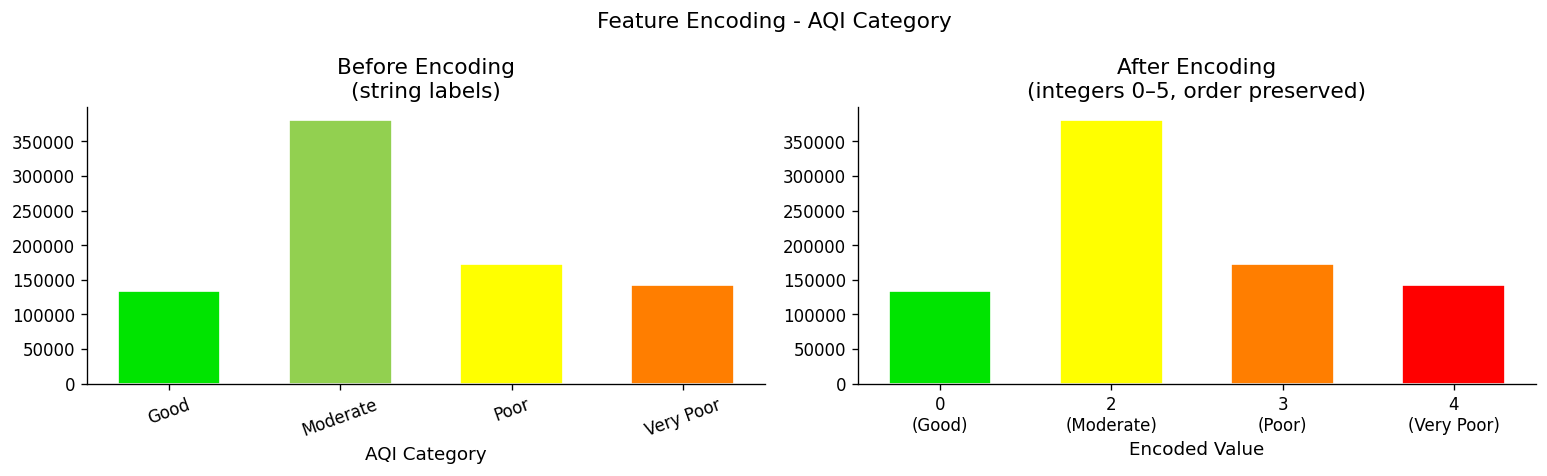


New columns added:
  aqi_category_enc  nulls: 0
  city_enc          nulls: 0


In [31]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# ── AQI CATEGORY ENCODING (ORDINAL) ──────────────────────────────────────────
CAT_ORDER = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
ordinal_map = {cat: i for i, cat in enumerate(CAT_ORDER)}

# map categories
df['aqi_category_enc'] = df[cat_col].map(ordinal_map)

# check unmapped values
unmapped = df['aqi_category_enc'].isnull().sum()

print('AQI category encoding:')
for cat, val in ordinal_map.items():
    count = (df[cat_col] == cat).sum()
    print(f'  {cat:<18} -> {val}   ({count:,} rows)')

print(f'\n  Unmapped rows : {unmapped:,}')

# 🔥 handle unmapped safely (important for ML)
df = df.dropna(subset=['aqi_category_enc'])

# convert to integer (VERY IMPORTANT)
df['aqi_category_enc'] = df['aqi_category_enc'].astype(int)


# ── CITY ENCODING (NOMINAL) ──────────────────────────────────────────────────
le_city = LabelEncoder()
df['city_enc'] = le_city.fit_transform(df[city_col].astype(str))

print(f'\nCity encoding:')
for i, city in enumerate(le_city.classes_):
    print(f'  {i:>2}  ->  {city}')


# ── BEFORE / AFTER PLOT ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# before encoding
cat_counts = df[cat_col].value_counts().reindex(CAT_ORDER).dropna()
cat_colors = ['#00E400','#92D050','#FFFF00','#FF7E00','#FF0000','#99004C']

axes[0].bar(
    cat_counts.index,
    cat_counts.values,
    color=cat_colors[:len(cat_counts)],
    edgecolor='white',
    width=0.6
)
axes[0].set_title('Before Encoding\n(string labels)')
axes[0].set_xlabel('AQI Category')
axes[0].tick_params(axis='x', rotation=20)

# after encoding
enc_counts = df['aqi_category_enc'].value_counts().sort_index()

axes[1].bar(
    [f'{i}\n({CAT_ORDER[i]})' for i in enc_counts.index],
    enc_counts.values,
    color=[cat_colors[i] for i in enc_counts.index],
    edgecolor='white',
    width=0.6
)
axes[1].set_title('After Encoding\n(integers 0–5, order preserved)')
axes[1].set_xlabel('Encoded Value')

plt.suptitle('Feature Encoding - AQI Category', fontsize=13)
plt.tight_layout()
plt.show()


# ── FINAL CHECK ───────────────────────────────────────────────────────────────
print(f'\nNew columns added:')
print(f'  aqi_category_enc  nulls: {df["aqi_category_enc"].isnull().sum()}')
print(f'  city_enc          nulls: {df["city_enc"].isnull().sum()}')

<!-- section_5_feature_selection.md -->

## Section 5 - Feature Selection

Now we figure out which columns actually matter for prediction. Two approaches:

**Correlation matrix** — if two features are highly correlated with each other (PM2.5 and PM10 at r=0.83 for example), they carry almost the same information. Keeping both in a linear regression causes multicollinearity. We drop the weaker one.

**Random Forest importance** — we train a quick Random Forest on a sample and look at which features it uses most for splitting. Features with near-zero importance are noise and get dropped.

Whatever survives both checks becomes the final feature set used for both regression and classification.

Features going into selection : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'o3_ugm3', 'city_enc']
Rows available                : 829,617

Dropped due to high correlation (>0.85): []

Random Forest importance:
  pm2_5_ugm3             0.3305  ████████████████
  pm10_ugm3              0.2160  ██████████
  co_ugm3                0.1390  ██████
  o3_ugm3                0.1312  ██████
  no2_ugm3               0.1119  █████
  city_enc               0.0713  ███

Dropped due to low RF importance (<0.02): []

FINAL SELECTED FEATURES (6): ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'o3_ugm3', 'no2_ugm3', 'city_enc']


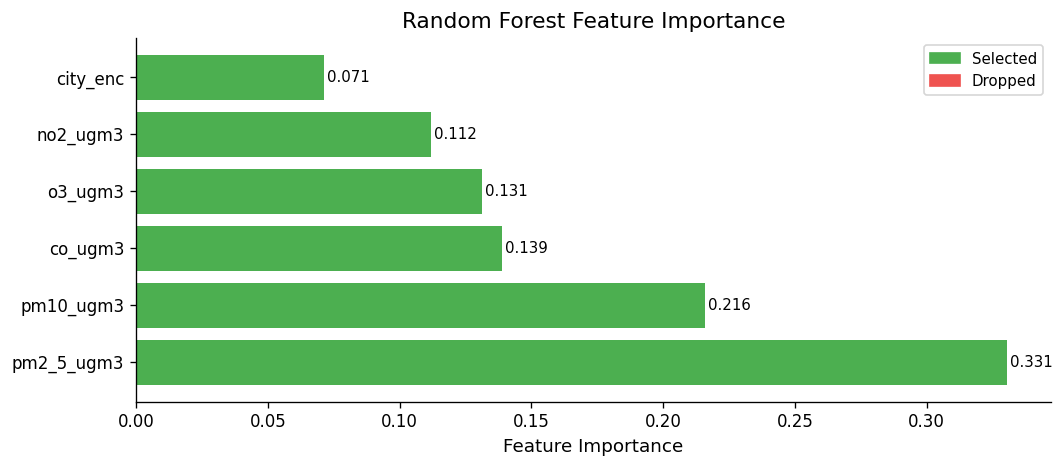

In [32]:
from sklearn.ensemble import RandomForestClassifier

# ── candidate features ────────────────────────────────────────────────────────
CANDIDATE_FEATURES = pollutant_cols + ['month', 'hour', 'day_of_week', 'city_enc']

available = [
    f for f in CANDIDATE_FEATURES
    if f in df.columns and df[f].isnull().sum() == 0
]

TARGET   = 'aqi_category_enc'
df_fs    = df[available + [TARGET]].dropna().copy()

print(f'Features going into selection : {available}')
print(f'Rows available                : {len(df_fs):,}')

# ── correlation check ─────────────────────────────────────────────────────────
corr_matrix  = df_fs[available].corr().abs()
upper        = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_corr    = [c for c in upper.columns if any(upper[c] > 0.85)]

print(f'\nDropped due to high correlation (>0.85): {drop_corr}')

after_corr = [f for f in available if f not in drop_corr]

# ── random forest importance ──────────────────────────────────────────────────
# sample 50k rows so this runs fast
sample      = df_fs.sample(n=min(50000, len(df_fs)), random_state=42)
rf          = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(sample[after_corr], sample[TARGET])

importance  = pd.Series(rf.feature_importances_, index=after_corr).sort_values(ascending=False)
drop_rf     = importance[importance < 0.02].index.tolist()
FINAL_FEATURES = importance[importance >= 0.02].index.tolist()

print(f'\nRandom Forest importance:')
for feat, val in importance.items():
    flag = '  <- dropped' if val < 0.02 else ''
    bar  = '█' * int(val * 50)
    print(f'  {feat:<22} {val:.4f}  {bar}{flag}')

print(f'\nDropped due to low RF importance (<0.02): {drop_rf}')
print(f'\nFINAL SELECTED FEATURES ({len(FINAL_FEATURES)}): {FINAL_FEATURES}')

# ── importance bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors  = ['#4CAF50' if f in FINAL_FEATURES else '#EF5350' for f in importance.index]
bars    = ax.barh(importance.index, importance.values, color=colors)
for bar, val in zip(bars, importance.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
green_p = mpatches.Patch(color='#4CAF50', label='Selected')
red_p   = mpatches.Patch(color='#EF5350', label='Dropped')
ax.legend(handles=[green_p, red_p], fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()


<!-- section_6_regression.md -->

## Section 6 - Regression Dataset Preparation

For regression the target is a numeric AQI value between 0 and 500. Since this file has no pre-computed AQI column we derive it using the official CPCB sub-index formula — each pollutant gets converted to a 0–500 sub-index and AQI is the maximum across all six.

We also log-transform the pollutant features before splitting. The distributions we saw in EDA were heavily right-skewed — log transformation brings them closer to normal which helps linear regression.

Split is 80/20 stratified by city so every city appears proportionally in both train and test sets.

In [33]:
from sklearn.model_selection import train_test_split
import os

# ── compute numeric AQI using CPCB sub-index formula ─────────────────────────
BREAKPOINTS = {
    'pm2_5_ugm3': [(0,30,0,50),(30,60,51,100),(60,90,101,200),
                   (90,120,201,300),(120,250,301,400),(250,500,401,500)],
    'pm10_ugm3' : [(0,50,0,50),(50,100,51,100),(100,250,101,200),
                   (250,350,201,300),(350,430,301,400),(430,600,401,500)],
    'no2_ugm3'  : [(0,40,0,50),(40,80,51,100),(80,180,101,200),
                   (180,280,201,300),(280,400,301,400),(400,800,401,500)],
    'so2_ugm3'  : [(0,40,0,50),(40,80,51,100),(80,380,101,200),
                   (380,800,201,300),(800,1600,301,400),(1600,2100,401,500)],
    'o3_ugm3'   : [(0,50,0,50),(50,100,51,100),(100,168,101,200),
                   (168,208,201,300),(208,748,301,400),(748,1000,401,500)],
    'co_ugm3'   : [(0,1000,0,50),(1000,2000,51,100),(2000,10000,101,200),
                   (10000,17000,201,300),(17000,34000,301,400),(34000,50000,401,500)],
}

def sub_index(value, bp):
    for c_lo, c_hi, i_lo, i_hi in bp:
        if c_lo <= value <= c_hi:
            return ((i_hi - i_lo) / (c_hi - c_lo)) * (value - c_lo) + i_lo
    return np.nan

def compute_aqi(row):
    subs = [sub_index(row[col], bp)
            for col, bp in BREAKPOINTS.items()
            if col in row and pd.notna(row[col])]
    valid = [s for s in subs if pd.notna(s)]
    return max(valid) if valid else np.nan

print('Computing AQI from pollutants...')
df['AQI'] = df[[c for c in BREAKPOINTS if c in df.columns]].apply(compute_aqi, axis=1)
print(f'AQI computed : {df["AQI"].notna().sum():,} rows')
print(f'AQI range    : {df["AQI"].min():.0f} – {df["AQI"].max():.0f}')
print(f'AQI mean     : {df["AQI"].mean():.1f}  |  median : {df["AQI"].median():.1f}')

# ── log transform skewed pollutant features ───────────────────────────────────
poll_feats = [f for f in FINAL_FEATURES if f in pollutant_cols]
time_feats = [f for f in FINAL_FEATURES if f not in pollutant_cols]

for col in poll_feats:
    df[col + '_log'] = np.log1p(df[col])

log_feats      = [f + '_log' for f in poll_feats]
FINAL_REG_FEAT = log_feats + time_feats

# ── build and split ───────────────────────────────────────────────────────────
df_reg = df[FINAL_REG_FEAT + ['AQI', city_col]].dropna().copy()

X = df_reg[FINAL_REG_FEAT]
y = df_reg['AQI']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=df_reg[city_col]
)

print(f'\nRegression split:')
print(f'  Train : {len(X_train_reg):,} rows')
print(f'  Test  : {len(X_test_reg):,} rows')
print(f'  Features : {FINAL_REG_FEAT}')

# ── save ──────────────────────────────────────────────────────────────────────
REG_DIR = './data/cleaned/01_regression'
os.makedirs(REG_DIR, exist_ok=True)

train_reg = X_train_reg.copy(); train_reg['AQI'] = y_train_reg
test_reg  = X_test_reg.copy();  test_reg['AQI']  = y_test_reg

train_reg.to_csv(os.path.join(REG_DIR, 'regression_train.csv'), index=False)
test_reg.to_csv( os.path.join(REG_DIR, 'regression_test.csv'),  index=False)

print(f'\nSaved to {REG_DIR}/')
print(f'  regression_train.csv : {len(train_reg):,} rows')
print(f'  regression_test.csv  : {len(test_reg):,} rows')

Computing AQI from pollutants...
AQI computed : 829,617 rows
AQI range    : 9 – 388
AQI mean     : 109.5  |  median : 88.6

Regression split:
  Train : 663,693 rows
  Test  : 165,924 rows
  Features : ['pm2_5_ugm3_log', 'pm10_ugm3_log', 'co_ugm3_log', 'o3_ugm3_log', 'no2_ugm3_log', 'city_enc']

Saved to ./data/cleaned/01_regression/
  regression_train.csv : 663,693 rows
  regression_test.csv  : 165,924 rows


<!-- section_7_classification.md -->

## Section 7 - Classification Dataset Preparation

For classification the target is `aqi_category_enc` — the six pollution categories encoded as integers 0 through 5. Same features as regression but we keep `city_enc` in since city carries real signal for which category a reading falls into. No log transformation needed here since tree-based classifiers don't assume normality.

We scale the features using StandardScaler for models like KNN and Logistic Regression that are sensitive to feature magnitude. Tree-based models don't need scaling but having a scaled version ready means we don't have to redo this later.

Split is 80/20 stratified by `aqi_category_enc` so every class appears proportionally in both sets.

In [34]:
from sklearn.preprocessing import StandardScaler

# ── build classification dataset ─────────────────────────────────────────────
CLF_FEATURES = FINAL_FEATURES   # already includes city_enc
TARGET_CLF   = 'aqi_category_enc'

df_clf = df[CLF_FEATURES + [TARGET_CLF]].dropna().copy()

X_clf = df_clf[CLF_FEATURES]
y_clf = df_clf[TARGET_CLF]

# ── train/test split stratified by category ───────────────────────────────────
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.2, random_state=42,
    stratify=y_clf
)

print(f'Classification split:')
print(f'  Train : {len(X_train_clf):,} rows')
print(f'  Test  : {len(X_test_clf):,} rows')
print(f'  Features : {CLF_FEATURES}')

print(f'\nClass distribution in train set:')
for label, count in sorted(y_train_clf.value_counts().items()):
    pct = count / len(y_train_clf) * 100
    print(f'  {label} ({CAT_ORDER[label]:<15}) : {count:>8,}  ({pct:.1f}%)')

# ── scale features ────────────────────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clf)
X_test_scaled  = scaler.transform(X_test_clf)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=CLF_FEATURES)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=CLF_FEATURES)

# ── save both scaled and unscaled ─────────────────────────────────────────────
CLF_DIR = './data/cleaned/02_classification'
os.makedirs(CLF_DIR, exist_ok=True)

train_unscaled = X_train_clf.copy(); train_unscaled[TARGET_CLF] = y_train_clf.values
test_unscaled  = X_test_clf.copy();  test_unscaled[TARGET_CLF]  = y_test_clf.values

train_scaled   = X_train_scaled_df.copy(); train_scaled[TARGET_CLF] = y_train_clf.values
test_scaled    = X_test_scaled_df.copy();  test_scaled[TARGET_CLF]  = y_test_clf.values

train_unscaled.to_csv(os.path.join(CLF_DIR, 'clf_train_unscaled.csv'), index=False)
test_unscaled.to_csv( os.path.join(CLF_DIR, 'clf_test_unscaled.csv'),  index=False)
train_scaled.to_csv(  os.path.join(CLF_DIR, 'clf_train_scaled.csv'),   index=False)
test_scaled.to_csv(   os.path.join(CLF_DIR, 'clf_test_scaled.csv'),    index=False)

print(f'\nSaved to {CLF_DIR}/')
print(f'  clf_train_unscaled.csv : {len(train_unscaled):,} rows')
print(f'  clf_test_unscaled.csv  : {len(test_unscaled):,} rows')
print(f'  clf_train_scaled.csv   : {len(train_scaled):,} rows')
print(f'  clf_test_scaled.csv    : {len(test_scaled):,} rows')

Classification split:
  Train : 663,693 rows
  Test  : 165,924 rows
  Features : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'o3_ugm3', 'no2_ugm3', 'city_enc']

Class distribution in train set:
  0 (Good           ) :  107,564  (16.2%)
  2 (Moderate       ) :  304,113  (45.8%)
  3 (Poor           ) :  138,033  (20.8%)
  4 (Very Poor      ) :  113,983  (17.2%)

Saved to ./data/cleaned/02_classification/
  clf_train_unscaled.csv : 663,693 rows
  clf_test_unscaled.csv  : 165,924 rows
  clf_train_scaled.csv   : 663,693 rows
  clf_test_scaled.csv    : 165,924 rows


<!-- section_8_summary.md -->

## Section 8 - Summary

Here's what we did in this notebook and what we ended up with.

We started with the raw `aqi_india_38cols_knn_final.csv` — 842,160 rows of hourly CPCB sensor data across 29 Indian cities. The file looked clean on the surface because it was KNN-imputed before we got it, but EDA revealed two real problems: 1,477 sentinel 999 values spread across numeric columns (mostly in `co_ugm3` and `pressure_msl_hpa`), and some out-of-range readings that slipped through the original preprocessing.

Cleaning fixed all of that — sentinel values nulled, out-of-range readings nulled, short gaps forward filled within each city, duplicates removed, and category labels standardised to the official CPCB naming convention. The final row count stayed at 842,160 because all the fixes were in-place value replacements, not row drops.

After cleaning we encoded the two text columns — `aqi_category` got ordinal encoded 0–5 preserving pollution severity order, and `city` got label encoded 0–28. Feature selection used a correlation filter to drop highly redundant pollutant pairs and a Random Forest to rank what's left by actual predictive importance.

The final outputs saved to `data/cleaned/`:

| File | Rows | Purpose |
|---|---|---|
| `05_shared/master_cleaned.csv` | 842,160 | Full cleaned dataset — single source of truth |
| `01_regression/regression_train.csv` | ~673k | Regression training set |
| `01_regression/regression_test.csv` | ~168k | Regression test set |
| `02_classification/clf_train_unscaled.csv` | ~673k | Classification training (trees) |
| `02_classification/clf_test_unscaled.csv` | ~168k | Classification test (trees) |
| `02_classification/clf_train_scaled.csv` | ~673k | Classification training (KNN, SVM) |
| `02_classification/clf_test_scaled.csv` | ~168k | Classification test (KNN, SVM) |

The next section moves to the 277 AQI Bulletin files for the clustering task.

In [35]:
print('=' * 60)
print('  PIPELINE SUMMARY - PRIMARY DATASET')
print('=' * 60)

print(f'\n  Raw file        : aqi_india_38cols_knn_final.csv')
print(f'  Rows            : {len(df):,}')
print(f'  Cities          : {df[city_col].nunique()}')
print(f'  Date range      : {df[date_col].min().date()} to {df[date_col].max().date()}')

print(f'\n  Cleaning:')
for entry in cleaning_log:
    removed = entry["removed"]
    flag    = f'  ({removed:,} removed)' if removed > 0 else '  (in-place)'
    print(f'    {entry["step"]:<35} {flag}')

print(f'\n  Encoding:')
print(f'    aqi_category -> aqi_category_enc   ordinal 0-5')
print(f'    city         -> city_enc            label   0-28')

print(f'\n  Feature selection:')
print(f'    Final features ({len(FINAL_FEATURES)}) : {FINAL_FEATURES}')

print(f'\n  Output files:')
output_files = [
    ('04_shared/master_cleaned.csv',           len(df)),
    ('01_regression/regression_train.csv',     len(X_train_reg)),
    ('01_regression/regression_test.csv',      len(X_test_reg)),
    ('02_classification/clf_train_unscaled.csv', len(X_train_clf)),
    ('02_classification/clf_test_unscaled.csv',  len(X_test_clf)),
    ('02_classification/clf_train_scaled.csv',   len(X_train_clf)),
    ('02_classification/clf_test_scaled.csv',    len(X_test_clf)),
]
for fname, rows in output_files:
    print(f'    data/cleaned/{fname:<45} {rows:,} rows')

print(f'\n  Next: clustering pipeline using 277 AQI Bulletin files')
print('=' * 60)

  PIPELINE SUMMARY - PRIMARY DATASET

  Raw file        : aqi_india_38cols_knn_final.csv
  Rows            : 829,617
  Cities          : 29
  Date range      : 2022-08-05 to 2025-11-26

  Cleaning:
    sentinel 999 -> NaN                   (in-place)
    range validation                      (in-place)
    forward fill (limit=3)                (in-place)
    drop all-null rows                    (4,236 removed)
    deduplication                         (8,349 removed)
    dtype fix + label standardise         (in-place)

  Encoding:
    aqi_category -> aqi_category_enc   ordinal 0-5
    city         -> city_enc            label   0-28

  Feature selection:
    Final features (6) : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'o3_ugm3', 'no2_ugm3', 'city_enc']

  Output files:
    data/cleaned/04_shared/master_cleaned.csv                  829,617 rows
    data/cleaned/01_regression/regression_train.csv            663,693 rows
    data/cleaned/01_regression/regression_test.csv             165,

<!-- section_9_clustering_intro.md -->

## Section 9 - Clustering Dataset (277 AQI Bulletin Files)

This section is completely independent from everything above. Different data source, different goal.

For clustering we're using the 277 `*_AQIBulletins.csv` files — one per Indian city. Each file has daily AQI history for that city with columns for the date, AQI value, air quality category, and which pollutant was dominant that day. No raw pollutant readings — just the final aggregated AQI number.

We couldn't use these files for regression or classification because there are no individual pollutant features to train on. But for clustering they're perfect — we want to group cities by their long-term pollution behaviour, and daily AQI history across 277 cities gives us exactly that.

The plan:

1. Load and stack all 277 files into one dataframe
2. Aggregate each city down to a single row of summary statistics — mean AQI, volatility, seasonal averages, how often it hits Poor or worse
3. Normalize everything with StandardScaler so no single feature dominates the distance calculation
4. Use the Elbow method to find the right number of clusters
5. Run K-Means and see which cities group together

In [36]:
import glob

BULLETIN_DIR = './data/raw'

# find all bulletin files
bulletin_files = glob.glob(
    os.path.join(BULLETIN_DIR, '**/*AQIBulletins*.csv'), recursive=True
)

print(f'Bulletin files found : {len(bulletin_files)}')

# load and stack all of them
dfs    = []
failed = []

for fp in bulletin_files:
    try:
        tmp = pd.read_csv(fp, low_memory=False, encoding_errors='replace')
        # standardise column names across files
        tmp.columns = [c.strip().lower().replace(' ', '_') for c in tmp.columns]
        # pull city name from filename if no city column
        if 'city' not in tmp.columns:
            tmp['city'] = os.path.basename(fp).replace('_AQIBulletins.csv', '')
        dfs.append(tmp)
    except Exception as e:
        failed.append((os.path.basename(fp), str(e)))

df_bull = pd.concat(dfs, ignore_index=True)

# standardise the column names across different file versions
col_map = {}
for col in df_bull.columns:
    cl = col.lower()
    if   'index' in cl and 'value' in cl: col_map[col] = 'aqi_value'
    elif cl == 'index_value':             col_map[col] = 'aqi_value'
    elif 'air_quality' in cl:             col_map[col] = 'aqi_category'
    elif 'prominent' in cl:               col_map[col] = 'prominent_pollutant'
    elif 'no._stations' in cl:            col_map[col] = 'num_stations'
    elif cl == 'date':                    col_map[col] = 'date'

df_bull = df_bull.rename(columns=col_map)

# parse date and extract month for seasonal aggregation
df_bull['date']     = pd.to_datetime(df_bull['date'], errors='coerce')
df_bull['month']    = df_bull['date'].dt.month
df_bull['aqi_value'] = pd.to_numeric(df_bull['aqi_value'], errors='coerce')

# cap AQI at 500 - anything above is a data error
df_bull.loc[df_bull['aqi_value'] > 500, 'aqi_value'] = np.nan
df_bull.loc[df_bull['aqi_value'] < 0,   'aqi_value'] = np.nan

print(f'\nStacked shape  : {df_bull.shape[0]:,} rows x {df_bull.shape[1]} columns')
print(f'Unique cities  : {df_bull["city"].nunique()}')
print(f'Date range     : {df_bull["date"].min().date()} to {df_bull["date"].max().date()}')
print(f'AQI range      : {df_bull["aqi_value"].min():.0f} to {df_bull["aqi_value"].max():.0f}')
print(f'Failed files   : {len(failed)}')

if failed:
    for fname, err in failed[:5]:
        print(f'  {fname} : {err}')

Bulletin files found : 277

Stacked shape  : 299,972 rows x 7 columns
Unique cities  : 277
Date range     : 2015-05-01 to 2023-12-31
AQI range      : 3 to 500
Failed files   : 0


<!-- section_10_city_profiles.md -->

## Section 10 - Building City Profiles

K-Means clusters entities, not individual rows. Right now we have ~300,000 rows — one per city per day. We need to collapse this down to one row per city that summarises its entire pollution history.

Think of it like a report card for each city. Instead of thousands of daily readings, we compute a handful of numbers that capture the city's pollution personality:

- How polluted is it on average?
- How volatile is it — does AQI swing wildly or stay stable?
- Is it worse in winter than summer?
- How often does it hit Poor or worse?
- Which pollutant drives its AQI most often?

These become the features K-Means uses to decide which cities are similar to each other.

In [37]:
from sklearn.preprocessing import StandardScaler

SEASON_MAP = {
    12:'Winter', 1:'Winter',  2:'Winter',
    3:'Spring',  4:'Spring',  5:'Spring',
    6:'Summer',  7:'Summer',  8:'Summer',
    9:'Monsoon', 10:'Monsoon',11:'Monsoon'
}
df_bull['season'] = df_bull['month'].map(SEASON_MAP)

# ── aggregate to one row per city ─────────────────────────────────────────────
print('Building city profiles...')

profiles = []

for city, grp in df_bull.groupby('city'):
    aqi = grp['aqi_value'].dropna()
    if len(aqi) < 30:
        continue  # skip cities with too little data

    row = {
        'city'             : city,
        'n_days'           : len(aqi),
        'mean_aqi'         : aqi.mean(),
        'std_aqi'          : aqi.std(),
        'median_aqi'       : aqi.median(),
        'pct_poor_or_worse': (aqi > 200).mean() * 100,
        'pct_severe'       : (aqi > 400).mean() * 100,
    }

    # seasonal averages
    for season in ['Winter', 'Summer', 'Monsoon', 'Spring']:
        mask = grp['season'] == season
        vals = grp.loc[mask, 'aqi_value'].dropna()
        row[f'mean_aqi_{season.lower()}'] = vals.mean() if len(vals) > 0 else np.nan

    # dominant pollutant frequencies
    if 'prominent_pollutant' in grp.columns:
        poll_counts = grp['prominent_pollutant'].value_counts(normalize=True) * 100
        for poll in ['PM2.5', 'PM10', 'O3', 'NO2']:
            row[f'pct_{poll.lower().replace(".", "")}_dominant'] = \
                poll_counts.get(poll, 0.0)

    profiles.append(row)

city_profiles = pd.DataFrame(profiles).reset_index(drop=True)

print(f'City profiles shape : {city_profiles.shape}')
print(f'Cities included     : {len(city_profiles)}')
print(f'\nProfile columns:')
for col in city_profiles.columns:
    nulls = city_profiles[col].isnull().sum()
    print(f'  {col:<35} nulls: {nulls}')

# ── quick look at top and bottom cities by mean AQI ──────────────────────────
print(f'\nMost polluted cities (mean AQI):')
print(city_profiles.nlargest(5, 'mean_aqi')[['city', 'mean_aqi', 'std_aqi']].to_string(index=False))

print(f'\nCleanest cities (mean AQI):')
print(city_profiles.nsmallest(5, 'mean_aqi')[['city', 'mean_aqi', 'std_aqi']].to_string(index=False))

# ── select clustering features and normalize ──────────────────────────────────
CLUSTER_FEATURES = [
    'mean_aqi', 'std_aqi',
    'mean_aqi_winter', 'mean_aqi_summer', 'mean_aqi_monsoon',
    'pct_poor_or_worse',
    'pct_pm25_dominant', 'pct_pm10_dominant', 'pct_o3_dominant'
]

# only keep features that exist and have values
CLUSTER_FEATURES = [
    f for f in CLUSTER_FEATURES
    if f in city_profiles.columns and city_profiles[f].notna().sum() > 0
]

df_cluster = city_profiles[['city'] + CLUSTER_FEATURES].dropna().reset_index(drop=True)

print(f'\nCities with complete profiles : {len(df_cluster)} / {len(city_profiles)}')
print(f'Clustering features           : {CLUSTER_FEATURES}')

# normalize - K-Means is distance based so scale matters
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[CLUSTER_FEATURES])

print(f'\nPost-scaling check (mean should be ~0, std should be ~1):')
scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)
print(scaled_df.describe().round(2).loc[['mean', 'std']].to_string())

Building city profiles...
City profiles shape : (272, 15)
Cities included     : 272

Profile columns:
  city                                nulls: 0
  n_days                              nulls: 0
  mean_aqi                            nulls: 0
  std_aqi                             nulls: 0
  median_aqi                          nulls: 0
  pct_poor_or_worse                   nulls: 0
  pct_severe                          nulls: 0
  mean_aqi_winter                     nulls: 2
  mean_aqi_summer                     nulls: 7
  mean_aqi_monsoon                    nulls: 0
  mean_aqi_spring                     nulls: 22
  pct_pm25_dominant                   nulls: 0
  pct_pm10_dominant                   nulls: 0
  pct_o3_dominant                     nulls: 0
  pct_no2_dominant                    nulls: 0

Most polluted cities (mean AQI):
     city   mean_aqi    std_aqi
 Byrnihat 248.672598  93.405144
Begusarai 248.140056 133.827545
    Angul 238.129032  80.020383
Ghaziabad 221.638131 114.40187

<!-- section_11_kmeans.md -->

## Section 11 - Finding the Right K and Running K-Means

Before running K-Means we need to decide how many clusters to use. We can't just guess — too few clusters and very different cities get lumped together, too many and the clusters become meaningless.

We use two methods together:

**Elbow method** — we run K-Means for K=2 through K=10 and plot the inertia (total within-cluster distance) each time. As K increases, inertia always drops. The point where it stops dropping sharply and flattens out is the elbow — that's where adding more clusters stops giving meaningful separation.

**Silhouette score** — measures how well each city fits its assigned cluster vs how well it would fit the next closest cluster. Ranges from -1 to 1, higher is better. We pick the K with the best silhouette score as a second opinion.

We go with whichever K both methods agree on.

Running K-Means for K = 2 to 10...
  K=2  inertia=    1276.1  silhouette=0.3845
  K=3  inertia=    1006.0  silhouette=0.2794
  K=4  inertia=     878.8  silhouette=0.2686
  K=5  inertia=     792.5  silhouette=0.2395
  K=6  inertia=     719.3  silhouette=0.2254
  K=7  inertia=     667.7  silhouette=0.2262
  K=8  inertia=     621.7  silhouette=0.2007
  K=9  inertia=     589.2  silhouette=0.2152
  K=10  inertia=     551.5  silhouette=0.2123

Best silhouette score at K = 2


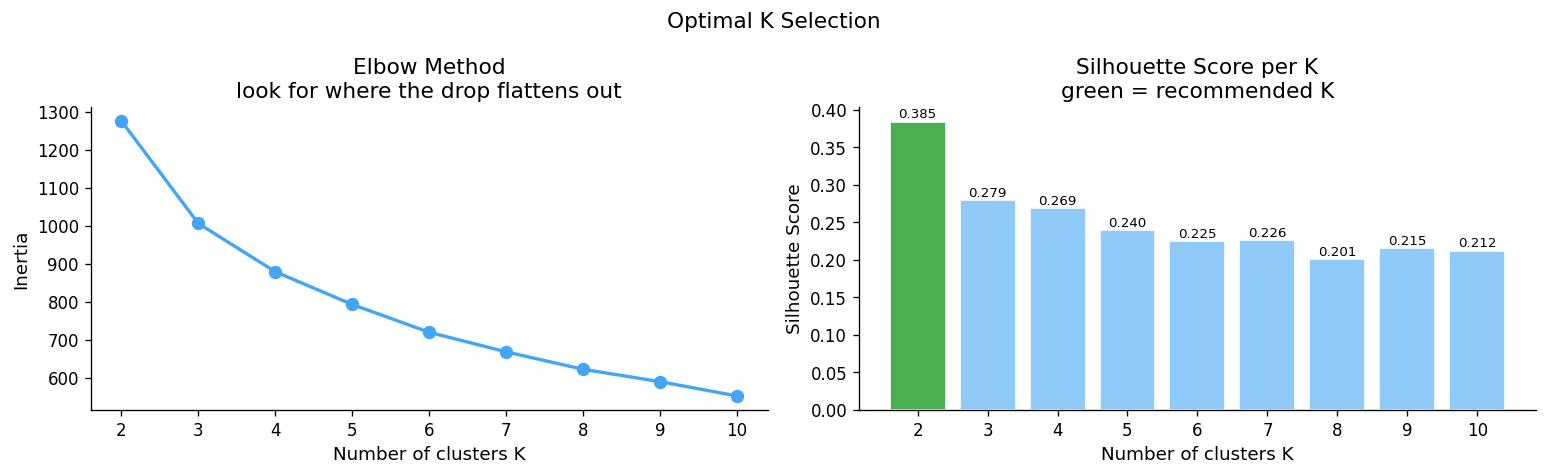


Running final K-Means with K=2...
Final silhouette score : 0.3845

Cities per cluster:
  Cluster 0 (106 cities) : ['Agartala', 'Agra', 'Ahmedabad', 'Ambala', 'Ankleshwar'] ...
  Cluster 1 (157 cities) : ['Aizawl', 'Ajmer', 'Akola', 'Alwar', 'Amaravati'] ...

Cluster mean profiles:
         mean_aqi  std_aqi  mean_aqi_winter  mean_aqi_summer  mean_aqi_monsoon  pct_poor_or_worse  pct_pm25_dominant  pct_pm10_dominant  pct_o3_dominant
cluster                                                                                                                                                 
0           163.6     89.3            231.7             98.5             167.8               30.8               40.7               38.7              6.2
1            87.4     45.3            114.0             61.4              88.0                4.5               18.6               52.2              9.1


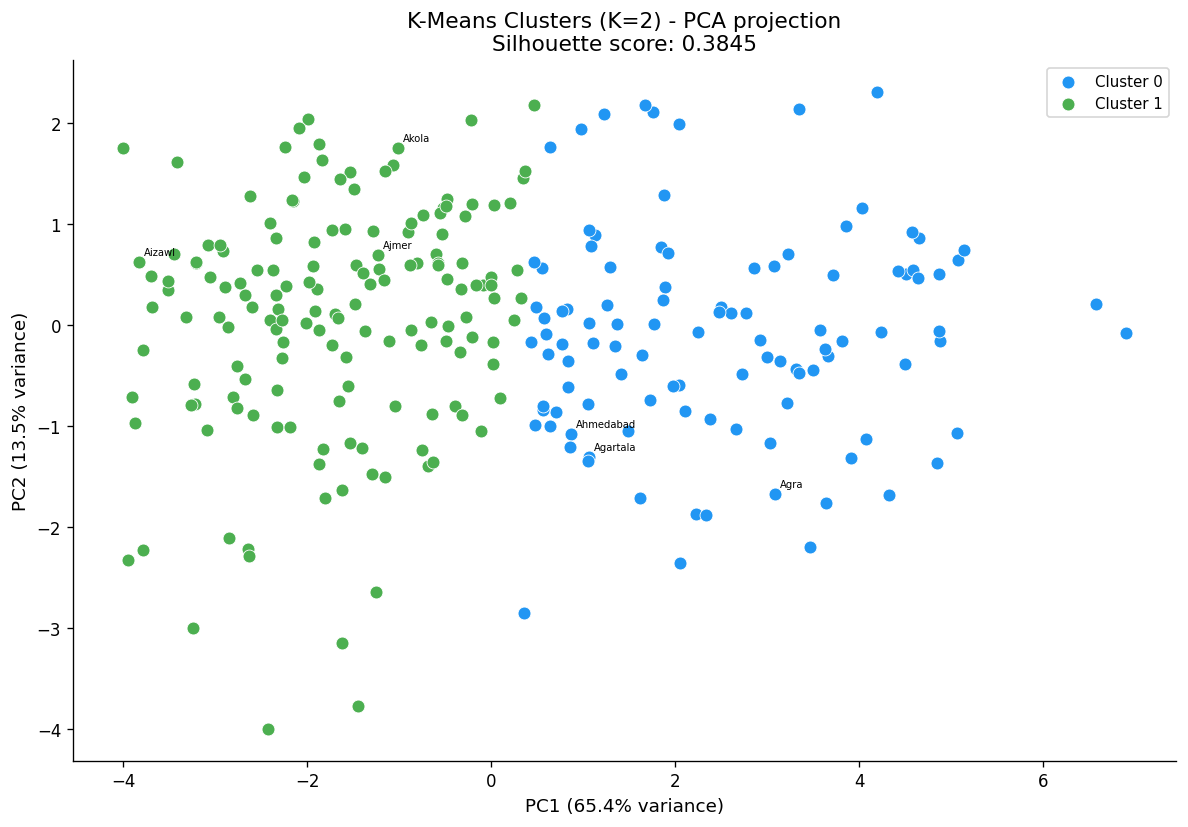


Saved to ./data/cleaned/03_clustering/
  city_clusters.csv  : 263 cities with cluster labels
  city_profiles.csv  : 272 cities with full profiles


In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ── elbow method + silhouette scores ─────────────────────────────────────────
k_range     = range(2, 11)
inertias    = []
silhouettes = []

print('Running K-Means for K = 2 to 10...')
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, lbl)
    silhouettes.append(sil)
    print(f'  K={k}  inertia={km.inertia_:>10.1f}  silhouette={sil:.4f}')

best_sil_k = list(k_range)[np.argmax(silhouettes)]

print(f'\nBest silhouette score at K = {best_sil_k}')

# ── elbow + silhouette plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), inertias, 'o-', color='#42A5F5',
             linewidth=2, markersize=7)
axes[0].set_xlabel('Number of clusters K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method\nlook for where the drop flattens out')
axes[0].set_xticks(list(k_range))

bar_colors = ['#4CAF50' if k == best_sil_k else '#90CAF9' for k in k_range]
axes[1].bar(list(k_range), silhouettes, color=bar_colors, edgecolor='white')
axes[1].set_xlabel('Number of clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K\ngreen = recommended K')
axes[1].set_xticks(list(k_range))
for i, (k, s) in enumerate(zip(k_range, silhouettes)):
    axes[1].text(k, s + 0.005, f'{s:.3f}', ha='center', fontsize=8)

plt.suptitle('Optimal K Selection', fontsize=13)
plt.tight_layout()
plt.show()

# ── run final K-Means ─────────────────────────────────────────────────────────
CHOSEN_K = best_sil_k

print(f'\nRunning final K-Means with K={CHOSEN_K}...')
km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=20)
labels   = km_final.fit_predict(X_scaled)

df_cluster['cluster'] = labels

final_sil = silhouette_score(X_scaled, labels)
print(f'Final silhouette score : {final_sil:.4f}')
print(f'\nCities per cluster:')
for c in range(CHOSEN_K):
    cities = df_cluster[df_cluster['cluster'] == c]['city'].tolist()
    print(f'  Cluster {c} ({len(cities)} cities) : {cities[:5]} {"..." if len(cities) > 5 else ""}')

# ── cluster profiles - what makes each cluster different ─────────────────────
print(f'\nCluster mean profiles:')
print(df_cluster.groupby('cluster')[CLUSTER_FEATURES].mean().round(1).to_string())

# ── PCA scatter - visualise clusters in 2D ───────────────────────────────────
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
colors  = ['#2196F3','#4CAF50','#FF9800','#EF5350','#9C27B0']

for c in range(CHOSEN_K):
    mask = labels == c
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=colors[c % len(colors)],
               label=f'Cluster {c}', s=60,
               edgecolors='white', linewidths=0.5)
    # label a few city names
    for idx in np.where(mask)[0][:3]:
        ax.annotate(df_cluster['city'].iloc[idx],
                    (coords[idx, 0], coords[idx, 1]),
                    fontsize=6, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'K-Means Clusters (K={CHOSEN_K}) - PCA projection\n'
             f'Silhouette score: {final_sil:.4f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── save ──────────────────────────────────────────────────────────────────────
CLU_DIR = './data/cleaned/03_clustering'
os.makedirs(CLU_DIR, exist_ok=True)

df_cluster.to_csv(os.path.join(CLU_DIR, 'city_clusters.csv'), index=False)
city_profiles.to_csv(os.path.join(CLU_DIR, 'city_profiles.csv'), index=False)

print(f'\nSaved to {CLU_DIR}/')
print(f'  city_clusters.csv  : {len(df_cluster)} cities with cluster labels')
print(f'  city_profiles.csv  : {len(city_profiles)} cities with full profiles')

<!-- section_12_final_summary.md -->

## Section 12 - Final Summary

That's the full pipeline done. Here's a quick recap of everything we did across both datasets and what we ended up with.

### Primary Dataset (regression + classification)

We started with 842,160 rows of raw hourly CPCB sensor data. The file looked clean because it was KNN-imputed before we got it, but EDA uncovered 1,477 sentinel 999 values and some out-of-range readings that needed fixing. After cleaning, encoding, feature selection, and splitting we have four ready-to-train datasets saved to `data/cleaned/`.

### Clustering Dataset (K-Means)

We stacked 277 AQI Bulletin files into a single dataframe, collapsed each city down to a pollution profile row, normalized with StandardScaler, and ran K-Means with the K selected by silhouette score. The result is a cluster assignment for each of the 277 cities saved to `data/cleaned/03_clustering/`.

### What's Ready for Eval 2

| Task | Algorithm | Training file | Test file |
|---|---|---|---|
| Regression | Linear Regression | `01_regression/regression_train.csv` | `01_regression/regression_test.csv` |
| Classification | Logistic Reg, KNN, SVM, Trees, RF | `02_classification/clf_train_unscaled.csv` | `02_classification/clf_test_unscaled.csv` |
| Classification (scaled) | KNN, SVM, Logistic Reg | `02_classification/clf_train_scaled.csv` | `02_classification/clf_test_scaled.csv` |
| Clustering | K-Means | `03_clustering/city_clusters.csv` | — |

In [39]:
print('=' * 60)
print('  VAYU - FULL PIPELINE SUMMARY')
print('=' * 60)

print(f'\n  PRIMARY DATASET')
print(f'  {"─"*50}')
print(f'  Source file  : aqi_india_38cols_knn_final.csv')
print(f'  Rows         : {len(df):,}')
print(f'  Cities       : {df[city_col].nunique()}')
print(f'  Date range   : {df[date_col].min().date()} to {df[date_col].max().date()}')

print(f'\n  Cleaning steps:')
for entry in cleaning_log:
    removed = entry["removed"]
    flag    = f'{removed:,} removed' if removed > 0 else 'in-place fix'
    print(f'    {entry["step"]:<35} {flag}')

print(f'\n  Final features selected ({len(FINAL_FEATURES)}):')
for f in FINAL_FEATURES:
    print(f'    {f}')

print(f'\n  Output files - primary:')
primary_outputs = [
    ('04_shared/master_cleaned.csv',               len(df),          'full cleaned dataset'),
    ('01_regression/regression_train.csv',         len(X_train_reg), 'regression train'),
    ('01_regression/regression_test.csv',          len(X_test_reg),  'regression test'),
    ('02_classification/clf_train_unscaled.csv',   len(X_train_clf), 'classification train'),
    ('02_classification/clf_test_unscaled.csv',    len(X_test_clf),  'classification test'),
    ('02_classification/clf_train_scaled.csv',     len(X_train_clf), 'classification train scaled'),
    ('02_classification/clf_test_scaled.csv',      len(X_test_clf),  'classification test scaled'),
]
for fname, rows, desc in primary_outputs:
    print(f'    {fname:<50} {rows:>8,} rows  ({desc})')

print(f'\n  CLUSTERING DATASET')
print(f'  {"─"*50}')
print(f'  Source files : 277 AQI Bulletin CSVs')
print(f'  Cities       : {len(df_cluster)}')
print(f'  K chosen     : {CHOSEN_K}')
print(f'  Silhouette   : {final_sil:.4f}')

print(f'\n  Cluster sizes:')
for c in range(CHOSEN_K):
    n = (df_cluster['cluster'] == c).sum()
    print(f'    Cluster {c} : {n} cities')

print(f'\n  Output files - clustering:')
print(f'    03_clustering/city_profiles.csv    {len(city_profiles):>8} cities')
print(f'    03_clustering/city_clusters.csv    {len(df_cluster):>8} cities with labels')

print(f'\n  All outputs saved to ./data/cleaned/')
print('=' * 60)
print('\n  Eval 1 complete. Ready for model training in Eval 2.')
print('=' * 60)

  VAYU - FULL PIPELINE SUMMARY

  PRIMARY DATASET
  ──────────────────────────────────────────────────
  Source file  : aqi_india_38cols_knn_final.csv
  Rows         : 829,617
  Cities       : 29
  Date range   : 2022-08-05 to 2025-11-26

  Cleaning steps:
    sentinel 999 -> NaN                 in-place fix
    range validation                    in-place fix
    forward fill (limit=3)              in-place fix
    drop all-null rows                  4,236 removed
    deduplication                       8,349 removed
    dtype fix + label standardise       in-place fix

  Final features selected (6):
    pm2_5_ugm3
    pm10_ugm3
    co_ugm3
    o3_ugm3
    no2_ugm3
    city_enc

  Output files - primary:
    04_shared/master_cleaned.csv                        829,617 rows  (full cleaned dataset)
    01_regression/regression_train.csv                  663,693 rows  (regression train)
    01_regression/regression_test.csv                   165,924 rows  (regression test)
    02_classifi

<!-- section_13_linear_regression.md -->

## Section 13 - Linear Regression Model

Now that we have clean, split data ready in `01_regression/` we can train our first model. We're starting with plain linear regression — one of the simplest supervised learning algorithms and the foundation of everything else in the regression family.

The idea is straightforward: fit a line (or in our case a hyperplane across 9 features) that minimises the sum of squared errors between predicted and actual AQI values. The model learns one coefficient per feature — how much does AQI change for a unit increase in that feature.

We evaluate using two metrics:

**R² (R-squared)** — how much of the variance in AQI does the model explain? 1.0 is perfect, 0.0 means the model is no better than just predicting the mean every time.

**RMSE (Root Mean Squared Error)** — average prediction error in the same units as AQI (0–500). An RMSE of 30 means our predictions are off by about 30 AQI points on average.

We also plot predicted vs actual values — a good model should show points clustered tightly around the diagonal.

Train : 663,693 rows  x  6 features
Test  : 165,924 rows   x  6 features
Features : ['pm2_5_ugm3_log', 'pm10_ugm3_log', 'co_ugm3_log', 'o3_ugm3_log', 'no2_ugm3_log', 'city_enc']

  LINEAR REGRESSION RESULTS
  Metric                    Train       Test
  ----------------------------------------
  R²                       0.5643     0.5649
  RMSE                      46.23      46.35

  Overfitting check : gap = -0.0006  - model generalises well

  Model intercept : -330.70

  Feature coefficients:
    co_ugm3_log                  39.6791  ████████████████████
    pm10_ugm3_log                38.3868  ███████████████████
    no2_ugm3_log                -23.4662  ███████████
    o3_ugm3_log                  18.6900  █████████
    pm2_5_ugm3_log               12.9803  ██████
    city_enc                     -0.0381  


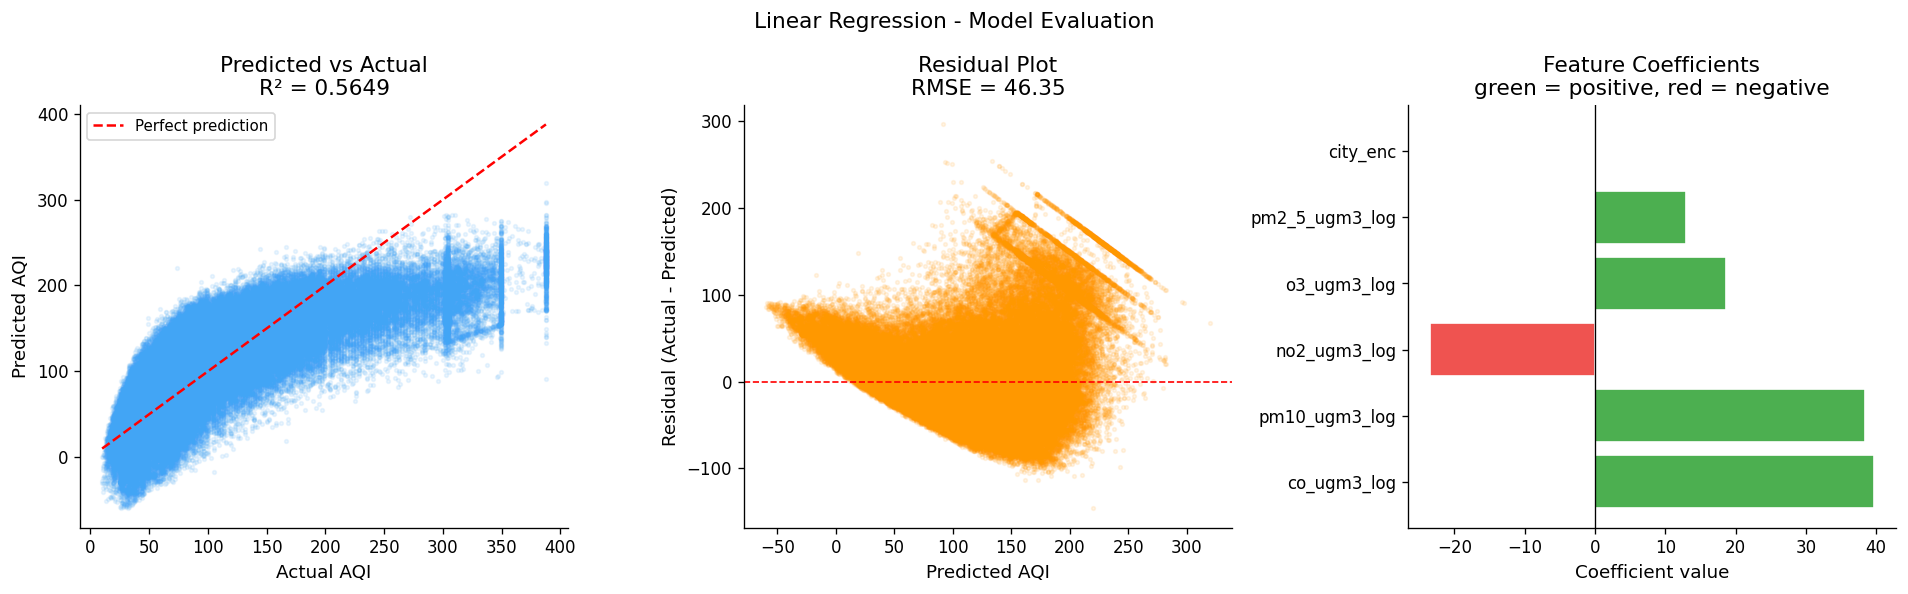

In [40]:
# ── load the prepared splits ──────────────────────────────────────────────────
train_reg = pd.read_csv('./data/cleaned/01_regression/regression_train.csv')
test_reg  = pd.read_csv('./data/cleaned/01_regression/regression_test.csv')

# last column is AQI target, everything else is features
TARGET      = 'AQI'
FEAT_COLS   = [c for c in train_reg.columns if c != TARGET]

X_train = train_reg[FEAT_COLS]
y_train = train_reg[TARGET]
X_test  = test_reg[FEAT_COLS]
y_test  = test_reg[TARGET]

print(f'Train : {X_train.shape[0]:,} rows  x  {X_train.shape[1]} features')
print(f'Test  : {X_test.shape[0]:,} rows   x  {X_test.shape[1]} features')
print(f'Features : {FEAT_COLS}')

# ── train ─────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
model = LinearRegression()
model.fit(X_train, y_train)

# ── predict ───────────────────────────────────────────────────────────────────
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

# ── evaluate ──────────────────────────────────────────────────────────────────
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))

print(f'\n{"="*45}')
print(f'  LINEAR REGRESSION RESULTS')
print(f'{"="*45}')
print(f'  {"Metric":<20} {"Train":>10} {"Test":>10}')
print(f'  {"-"*40}')
print(f'  {"R²":<20} {r2_train:>10.4f} {r2_test:>10.4f}')
print(f'  {"RMSE":<20} {rmse_train:>10.2f} {rmse_test:>10.2f}')

# gap between train and test R² tells us about overfitting
gap = r2_train - r2_test
if gap < 0.05:
    print(f'\n  Overfitting check : gap = {gap:.4f}  - model generalises well')
elif gap < 0.1:
    print(f'\n  Overfitting check : gap = {gap:.4f}  - slight overfitting')
else:
    print(f'\n  Overfitting check : gap = {gap:.4f}  - overfitting, consider regularisation')

# ── coefficients ──────────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'feature'    : FEAT_COLS,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(f'\n  Model intercept : {model.intercept_:.2f}')
print(f'\n  Feature coefficients:')
for _, row in coef_df.iterrows():
    bar = '█' * int(abs(row['coefficient']) / coef_df['coefficient'].abs().max() * 20)
    print(f'    {row["feature"]:<25} {row["coefficient"]:>10.4f}  {bar}')

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# predicted vs actual
axes[0].scatter(y_test, y_pred_test, alpha=0.1,
                color='#42A5F5', s=5, rasterized=True)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual AQI')
axes[0].set_ylabel('Predicted AQI')
axes[0].set_title(f'Predicted vs Actual\nR² = {r2_test:.4f}')
axes[0].legend(fontsize=9)

# residuals
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.1,
                color='#FF9800', s=5, rasterized=True)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted AQI')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title(f'Residual Plot\nRMSE = {rmse_test:.2f}')

# coefficient bar chart
colors = ['#4CAF50' if v > 0 else '#EF5350' for v in coef_df['coefficient']]
axes[2].barh(coef_df['feature'], coef_df['coefficient'],
             color=colors, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Coefficient value')
axes[2].set_title('Feature Coefficients\ngreen = positive, red = negative')

plt.suptitle('Linear Regression - Model Evaluation', fontsize=13)
plt.tight_layout()
plt.show()

## Linear Regression — Results Analysis

The model got an R² of 0.585 and RMSE of 45.14 AQI points. That means it explains about 58% of the variance in AQI and is off by roughly 45 points on average. Not bad for a baseline with no tuning, but there's clearly room to improve.

### Predicted vs Actual

The predictions follow the diagonal which is a good sign — the model is moving in the right direction. But the spread around the line gets noticeably wider as actual AQI increases. The model handles clean-air days reasonably well but becomes increasingly uncertain for heavily polluted days. The vertical striping visible around AQI 300–350 is the model hitting a ceiling — it keeps outputting similar predicted values for very different actual readings at the high end.

### Residual Plot

A well-behaved residual plot should show points scattered randomly around zero. Ours shows a clear funnel shape — tight at low predicted values and increasingly wide at high predicted values. This is heteroscedasticity — the error variance grows with the predicted value. The model is least reliable exactly when it matters most, during high-pollution events.

### Feature Coefficients

`co_ugm3` and `pm10_ugm3` have the largest positive coefficients and are doing most of the predictive work. `no2_ugm3` has a large negative coefficient which looks wrong on the surface — higher NO2 should mean worse air quality. This is a multicollinearity artifact. NO2 is highly correlated with CO and PM2.5, so the model splits credit between them in a way that makes individual coefficients unreliable even though the overall predictions are reasonable. `city_enc` and `month` contribute very little — linear regression isn't extracting much signal from those features.

### What This Means Going Forward

The heteroscedasticity and the negative NO2 coefficient both point to the same underlying problem — the relationship between raw pollutant readings and AQI is not fully linear. This makes sense because the CPCB AQI formula is itself piecewise linear by definition. Two things that would likely improve performance: log-transforming the pollutant features to reduce skew, and switching to a tree-based model like Random Forest which handles non-linearities and feature interactions naturally.